In [5]:
%load_ext autoreload 
%autoreload 2
import xarray as xr
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import binned_statistic
from src.loading import (
    SATURATED_MAXPR_MIN,
    load_gpm_feature_stats,
    load_imerg_feature_stats,
    load_dyamond_feature_stats,
    load_archived_dyamond_feature_stats,
     load_pickled_archived_features
)
from src.plotting import (
    array_midpoints,
    discrete_cmap,
    plot_mean_stat,
    gpm_area_factor,
    gpm_area_factor_accurate,
)
from src.saving import save_figure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Feature Statistics

In [2]:
# Feature data are loaded into a dict of dicts (~30 sec)
Feature_Data_Dict = {
    'GPM-DYAMOND': {
        'OBS-GPM': load_gpm_feature_stats(threshold=1.0, res="0p05"),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum="15min", res="0p05"),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum="15min", res="0p05"),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum="15min", res="0p05"),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum="15min", res="0p05"),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum="15min", res="0p05"),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum="15min", res="0p05"),
    },

    'IMERG-DYAMOND': {
        'OBS-IMERG': load_imerg_feature_stats(threshold=1.0),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum="30min", res="0p1"),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum="30min", res="0p1"),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum="30min", res="0p1"),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum="30min", res="0p1"),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum="30min", res="0p1"),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum="30min", res="0p1"),
    }
}

# Grid Plots of Feature Sizes

In [3]:
def _get_source_line_params(source):
    if 'OBS' in source:
        color='black'
        lw = 2.5
        linestyle='solid'
    else:
        color=None
        lw = 1.0
        linestyle='solid'
    return {'color': color, 'lw': lw, 'linestyle': linestyle}

# Precipitation and Size Distributions

(157578, 33)
(814662, 31)
(1530638, 31)
(642168, 31)
(340993, 31)
(629642, 31)
(984413, 31)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Size_PDF_Res0p05_EdgeFracMax_0.0.pdf as PDF ...
(162306, 33)
(824036, 31)
(1539253, 31)
(652440, 31)
(347305, 31)
(640746, 31)
(989894, 31)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Size_PDF_Res0p05_EdgeFracMax_0.05.pdf as PDF ...
(169232, 33)
(844193, 31)
(1562506, 31)
(672563, 31)
(359686, 31)
(661560, 31)
(1005661, 31)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Size_PDF_Res0p05_EdgeFracMax_0.1.pdf as PDF ...
(183415, 33)
(899314, 31)
(1635039, 31)
(718657, 31)
(388182, 31)
(715033, 31)
(1052816, 31)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Size_PDF_Res0p05_EdgeFracMax_0.25.pdf as PDF ...
(193343, 33)
(948078, 31)
(1717491, 31)
(755004, 31)
(409640, 31)
(757824, 31)
(1109257, 31)
Saving /Users/pedro/Projects/Coding/gpm_dya

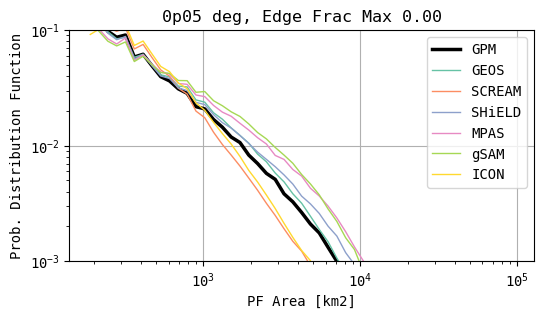

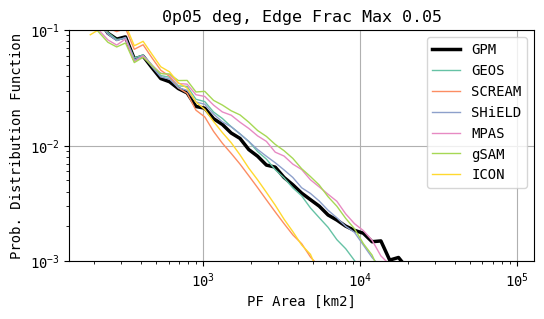

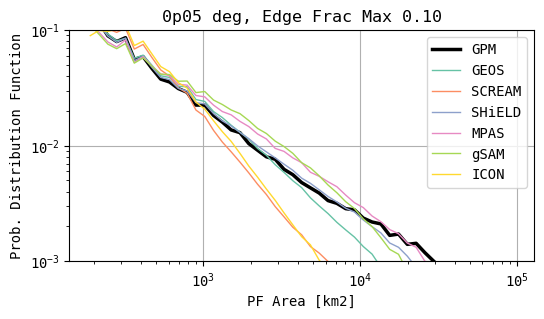

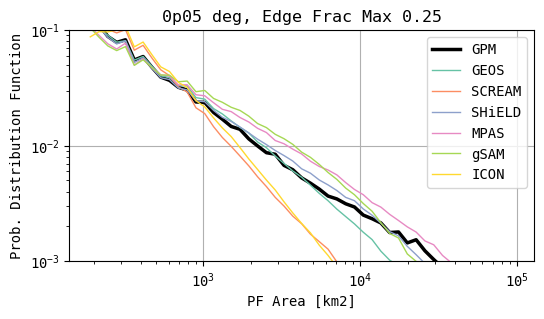

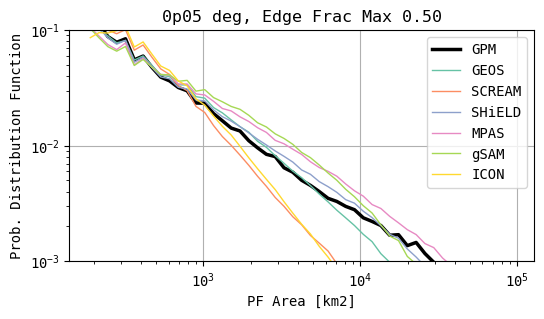

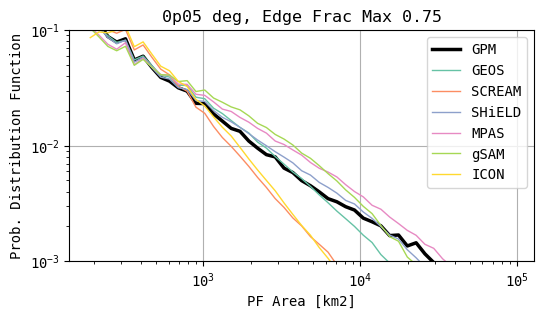

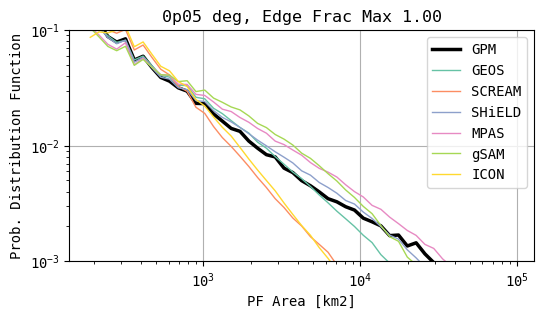

In [ ]:


for _EDGE_FRAC_MAX in [0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]:
    
    for source, df in feature_stats_dict.items():
        df = df.filter(
            pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX
        )
        
        bins = np.logspace(2.25, 5, 50)
        counts = binned_statistic(
            df['area_km2'],
            None,
            'count', 
            bins=bins
        ).statistic
        pdf = counts / counts.sum()

        line_params = _get_source_line_params(source)
        ax.plot(
            array_midpoints(bins),
            pdf,
            label=source,
            color=line_params['color'],
            lw=line_params['lw'],
            linestyle=line_params['linestyle']
        )

    ax.set_xscale('log')
    ax.legend()
    ax.grid()
    ax.set_ylim(1e-3, 1e-1)
    ax.set_yscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Prob. Distribution Function')
    ax.set_title(f'0p05 deg, Edge Frac Max {_EDGE_FRAC_MAX:.2f}')

    save_figure(fig,f'Size_PDF_Res{_RES}_EdgeFracMax_{_EDGE_FRAC_MAX}.pdf')


# Precipitation CDFs

source,n,q50,q90,q99,q99.9,frac_saturated
str,i64,f64,f64,f64,f64,f64
"""GPM""",195648,8.1,35.2,128.7,299.4,0.00109
"""GEOS""",969156,7.2,47.6,114.3,163.1,0.0
"""SCREAM""",1764297,8.1,41.4,98.1,141.6,0.0
"""SHiELD""",770803,6.9,34.4,80.4,127.5,0.0
"""MPAS""",417551,16.4,57.1,105.9,153.8,0.0
"""gSAM""",770869,10.4,47.5,92.9,128.0,0.0
"""ICON""",1140060,16.6,83.6,170.6,236.9,0.00006


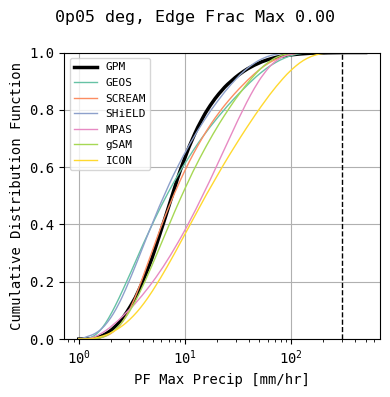

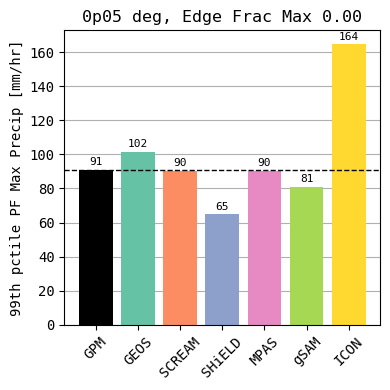

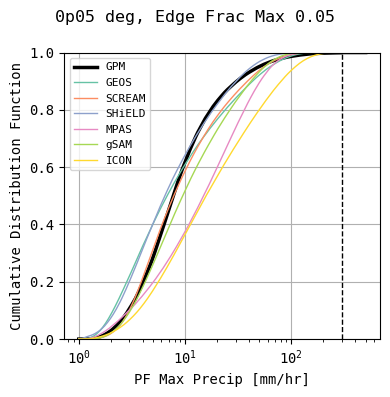

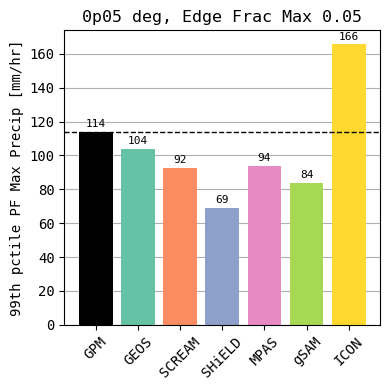

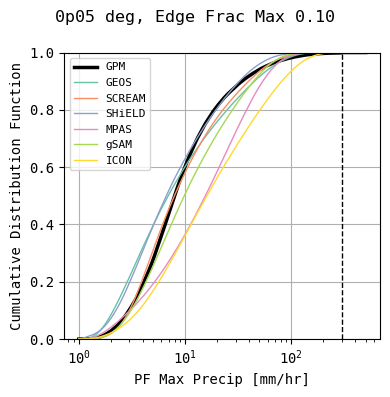

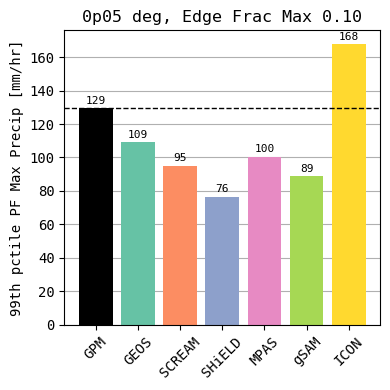

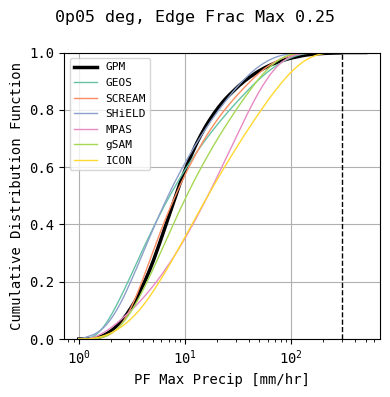

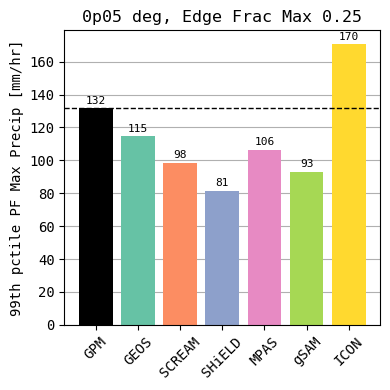

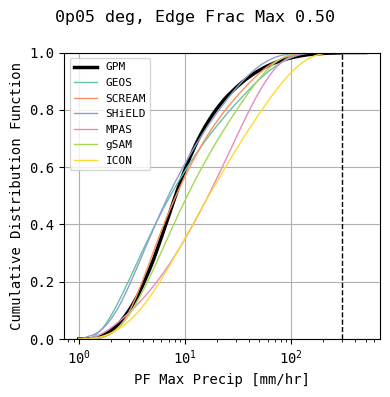

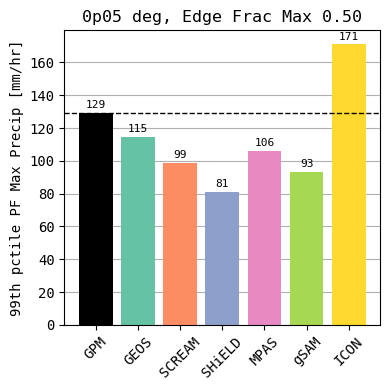

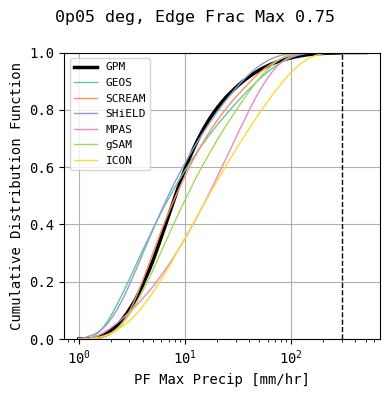

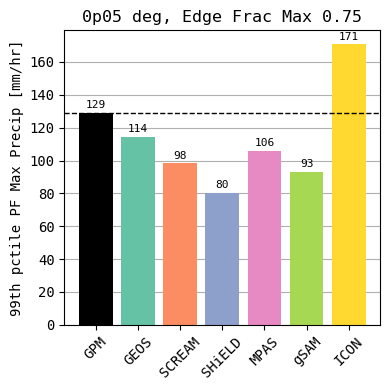

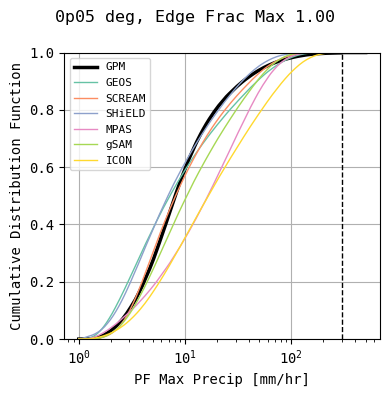

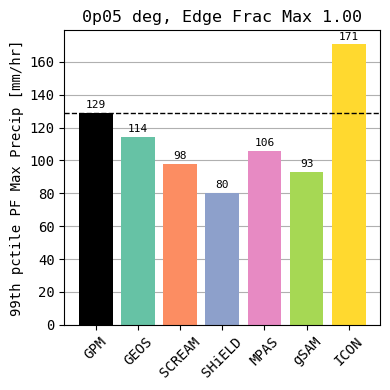

In [ ]:
def _get_source_line_params(source):
        if source == 'GPM':
            color='black'
            lw = 2.5
            linestyle='solid'
        elif source == "IMERG":
            color='black'
            lw = 2.5
            linestyle='dashed'
        else:
            color=None
            lw = 1.0
            linestyle='solid'

        return {'color': color, 'lw': lw, 'linestyle': linestyle}

# Evaluate the CDF on a fixed grid rather than on every feature: the tables have
# millions of rows, and searchsorted on the sorted values is exact anyway.
maxpr_grid = np.logspace(0, np.log10(500), 300)

for _EDGE_FRAC_MAX in [0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]:
    # Make the plot: CDF on the left, exceedance (1 - CDF) on the right for the tail
    fig, ax = plt.subplots(figsize=(4, 4))

    quantiles = []
    for source, df in feature_stats_dict.items():
        df = df.filter(
            pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX
        )

        maxpr = np.sort(df['max_precip_mm_hr'].to_numpy())
        cdf = np.searchsorted(maxpr, maxpr_grid, side='right') / maxpr.size

        line_params = _get_source_line_params(source)
        ax.plot(
            maxpr_grid,
            cdf,
            label=source,
            color=line_params['color'],
            lw=line_params['lw'],
            linestyle=line_params['linestyle']
            )

        quantiles.append({
            'source': source,
            'n': maxpr.size,
            **{f'q{q}': round(float(np.quantile(maxpr, q / 100)), 1) for q in [50, 90, 99, 99.9]},
            'frac_saturated': round(float((maxpr >= SATURATED_MAXPR_MIN).mean()), 5),
        })

    # GPM's retrieval saturates at 300 mm/hr, so everything to the right of this
    # line is piled up at the cap in the observations but not in the models.
    ax.axvline(SATURATED_MAXPR_MIN, color='black', lw=1, linestyle='dashed')
    ax.set_xscale('log')
    ax.grid()
    ax.set_xlabel('PF Max Precip [mm/hr]')

    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Cumulative Distribution Function')

    fig.suptitle(f'0p05 deg, Edge Frac Max {_EDGE_FRAC_MAX:.2f}')
    fig.tight_layout()

    # save_figure(fig, f'MaxPr_CDF_Res{_RES}_EdgeFracMax_{_EDGE_FRAC_MAX}.pdf')

    quantiles_df = pl.DataFrame(quantiles)

    # Bar plot of the same q99 values. Reuse the line colours: GPM/IMERG are given a
    # colour explicitly, the models fall through to the property cycle in plot order.
    bar_colors, _cycle_idx = [], 0
    for source in quantiles_df['source']:
        color = _get_source_line_params(source)['color']
        if color is None:
            color, _cycle_idx = f'C{_cycle_idx}', _cycle_idx + 1
        bar_colors.append(color)

    fig, ax = plt.subplots(figsize=(4, 4))
    bars = ax.bar(quantiles_df['source'].to_list(), quantiles_df['q99'].to_list(), color=bar_colors)
    ax.bar_label(bars, fmt='%.0f', fontsize=8, padding=2)

    # Reference line at the observed value, so the model bars read as a comparison
    if 'GPM' in quantiles_df['source'].to_list():
        ax.axhline(
            quantiles_df.filter(pl.col('source') == 'GPM')['q99'][0],
            color='black', lw=1, linestyle='dashed',
        )

    ax.grid(axis='y')
    ax.set_axisbelow(True)
    ax.set_ylabel('99th pctile PF Max Precip [mm/hr]')
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_title(f'0p05 deg, Edge Frac Max {_EDGE_FRAC_MAX:.2f}')
    fig.tight_layout()

    # save_figure(fig, f'MaxPr_q99_Bar_Res{_RES}_EdgeFracMax_{_EDGE_FRAC_MAX}.pdf')

    quantiles_df


# Joint Distributions

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extre

/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/plotting.py:69: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_SHiELD_EdgeFracMax0.05_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_MPAS_EdgeFracMax0.05_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_MPAS_EdgeFracMax0.05_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_gSAM_EdgeFracMax0.05_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_gSAM_EdgeFracMax0.05_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/AllPFs_A_CAF_JointPDF_ICON_EdgeFracMax0.05_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond

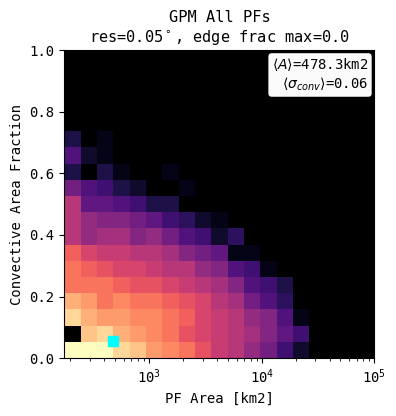

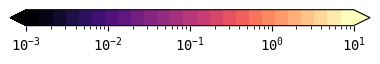

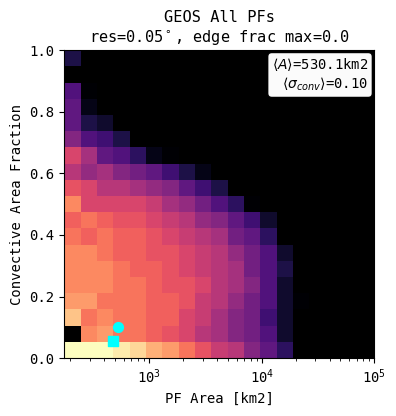

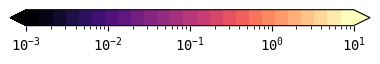

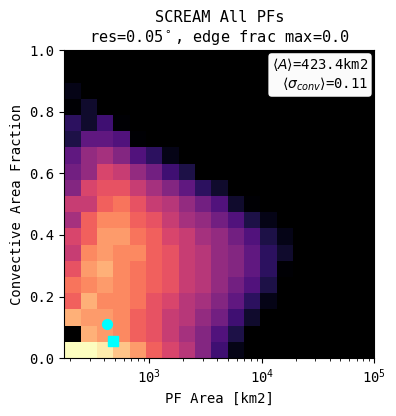

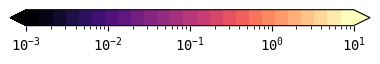

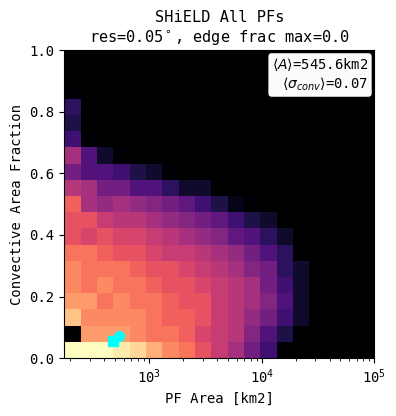

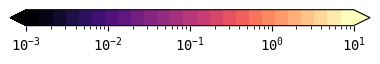

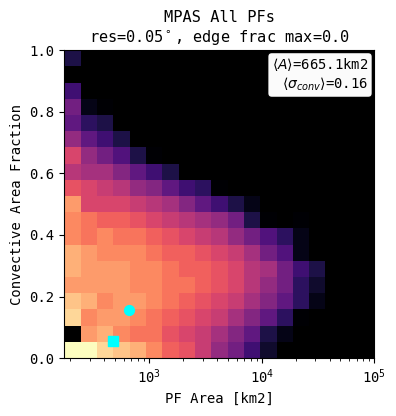

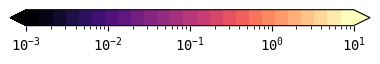

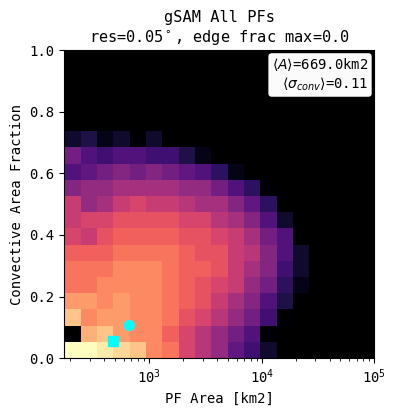

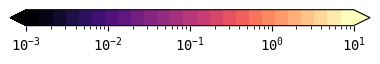

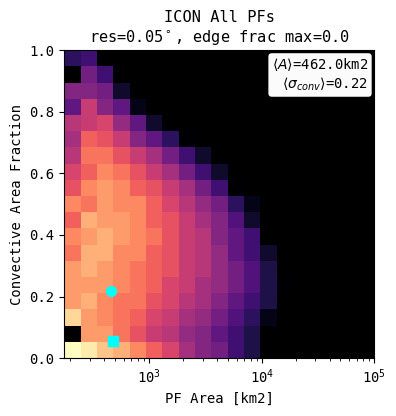

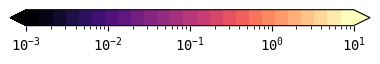

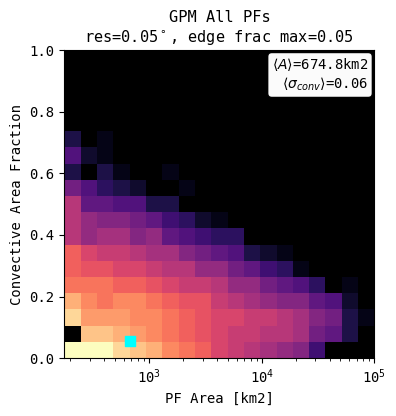

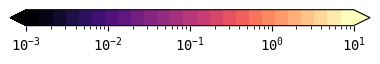

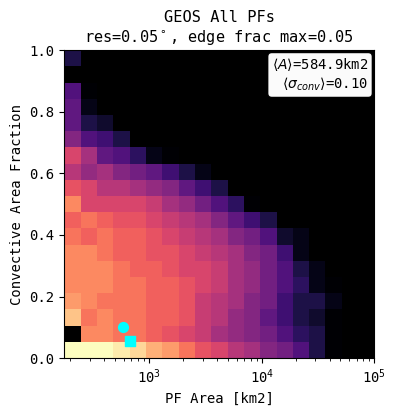

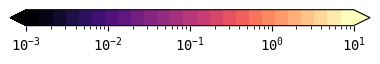

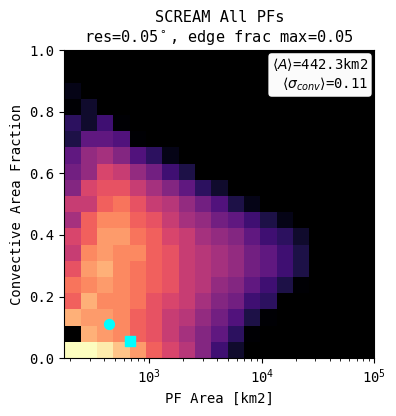

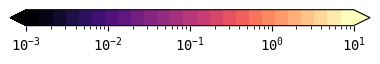

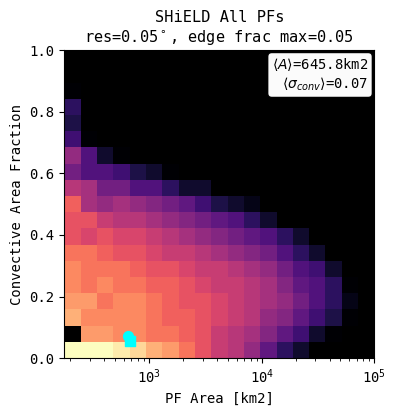

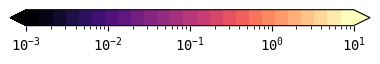

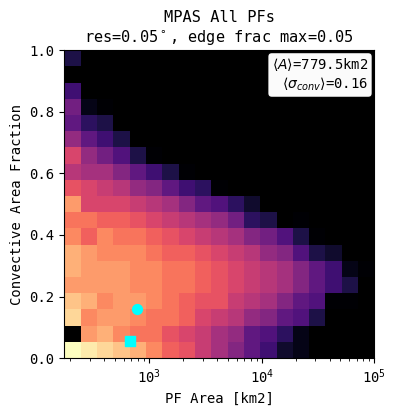

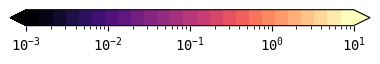

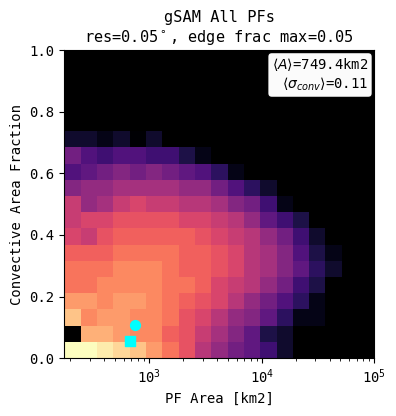

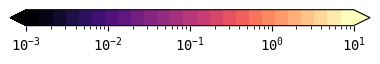

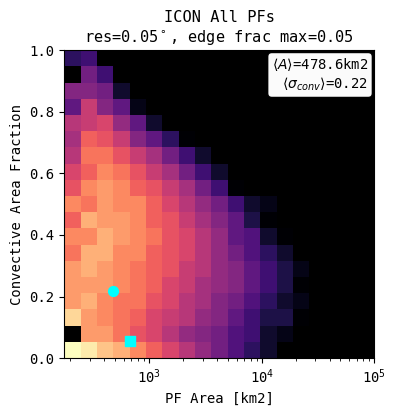

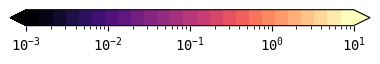

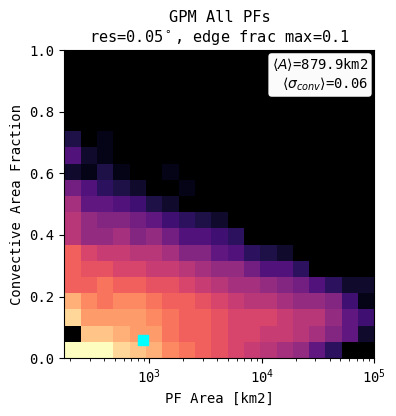

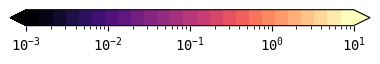

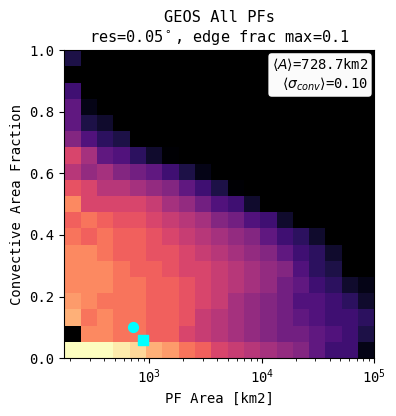

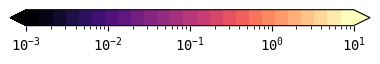

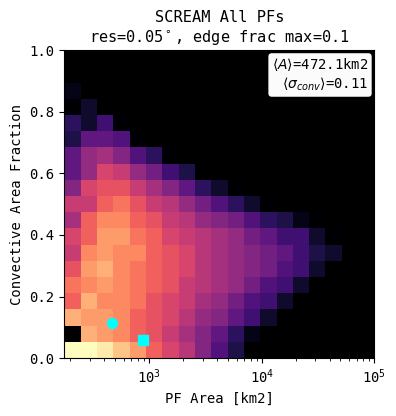

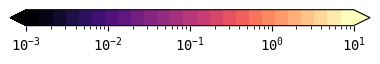

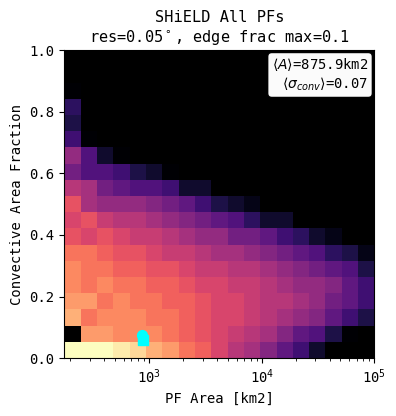

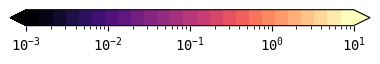

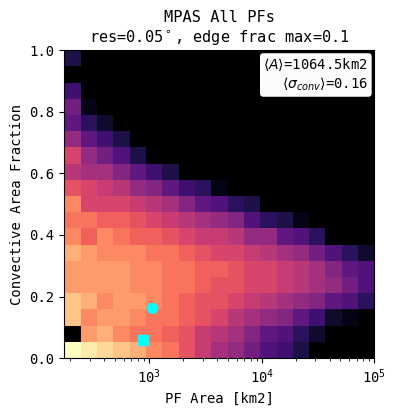

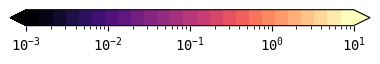

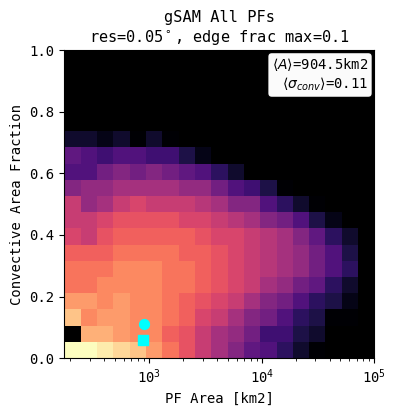

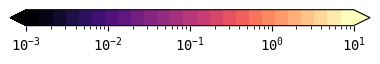

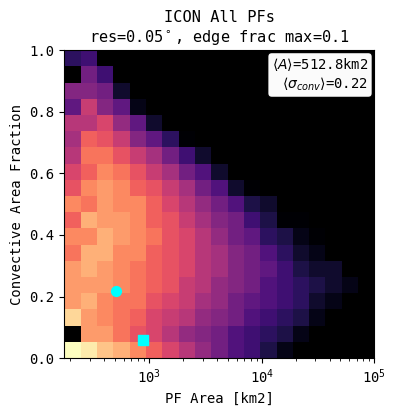

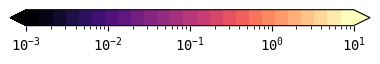

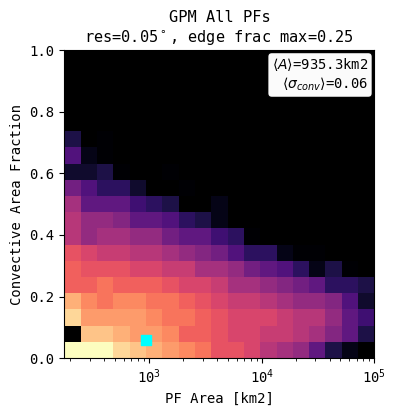

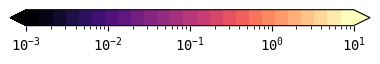

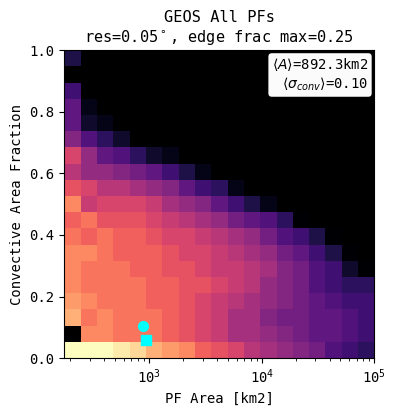

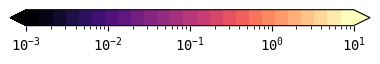

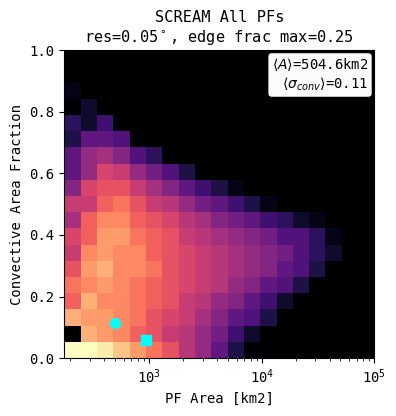

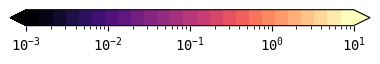

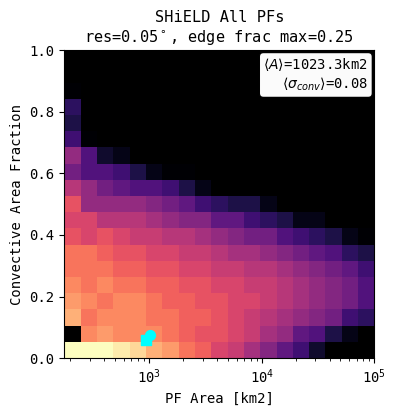

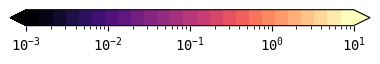

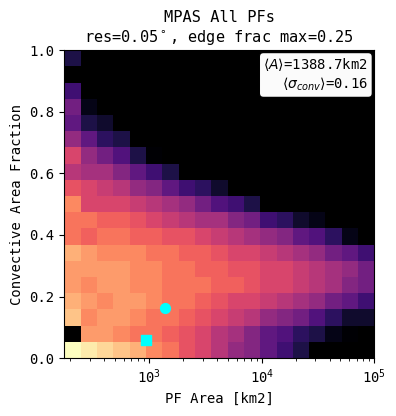

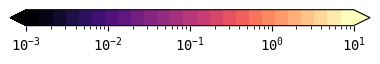

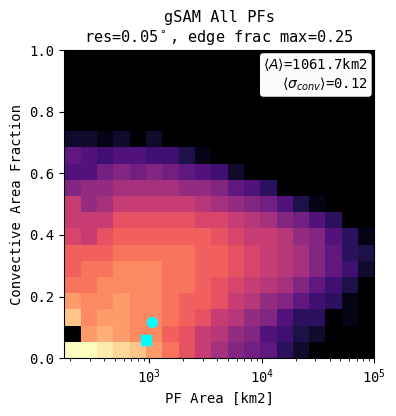

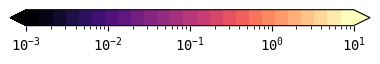

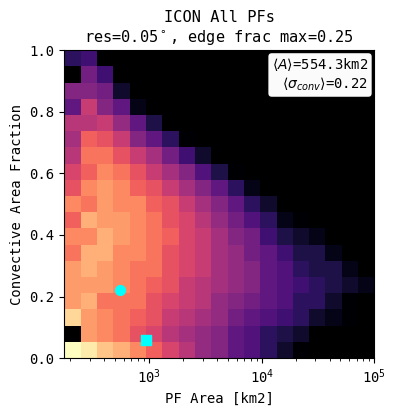

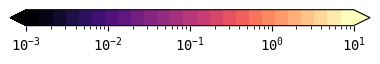

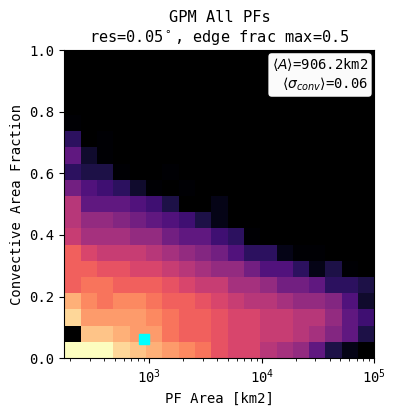

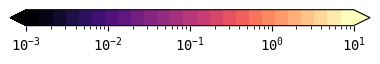

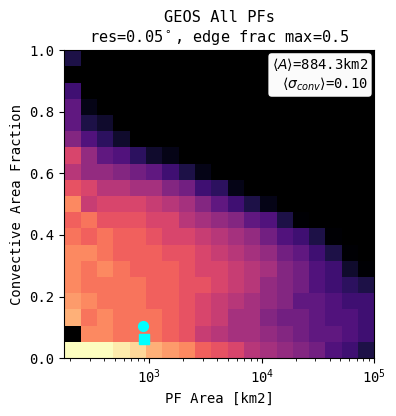

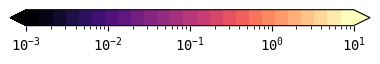

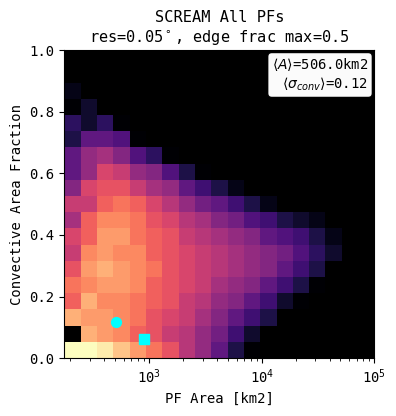

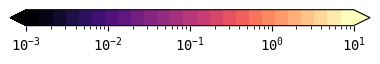

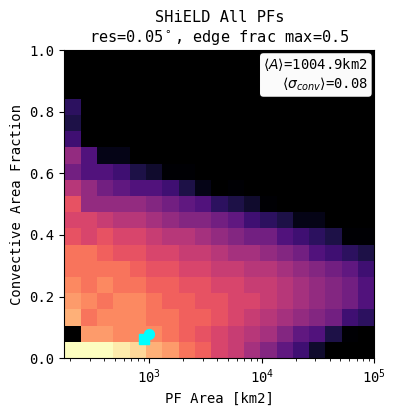

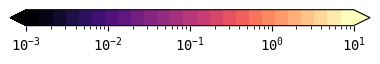

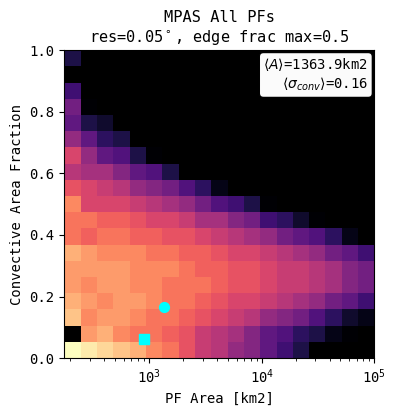

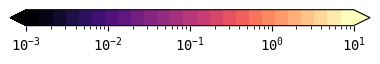

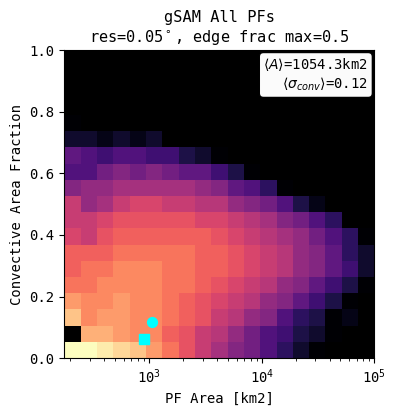

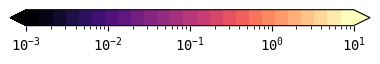

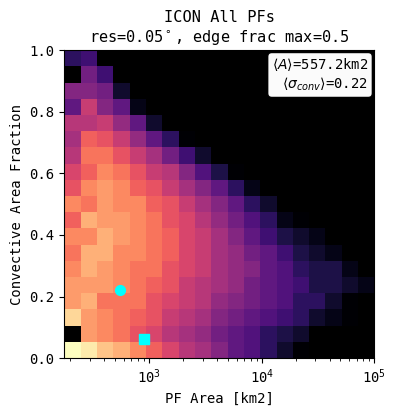

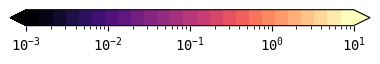

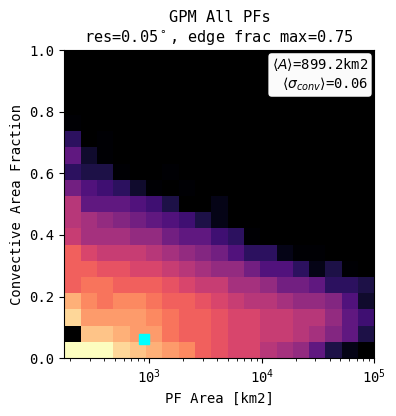

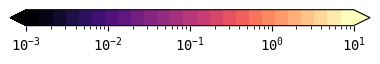

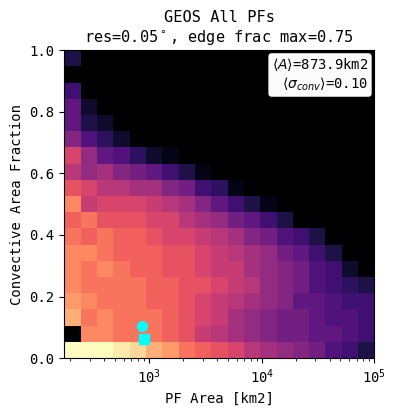

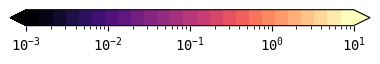

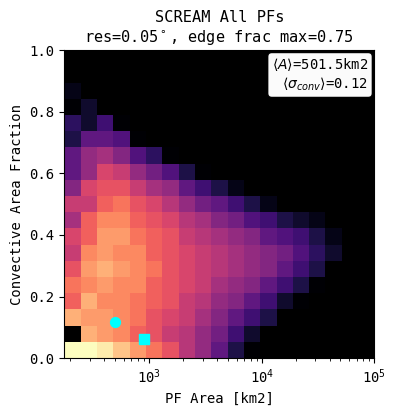

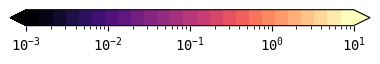

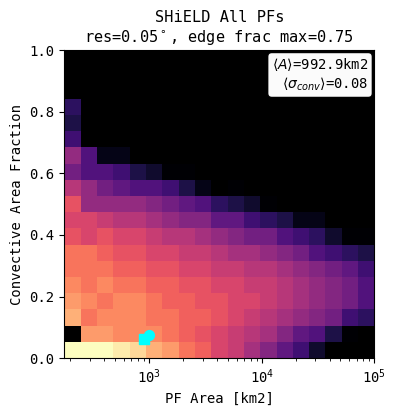

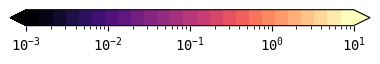

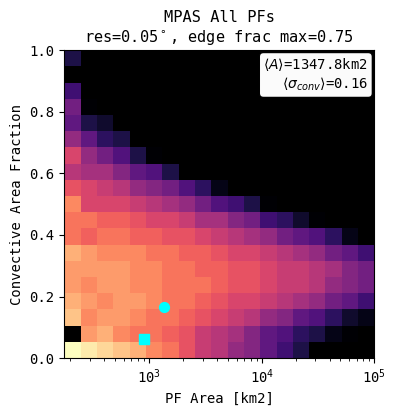

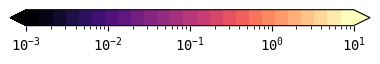

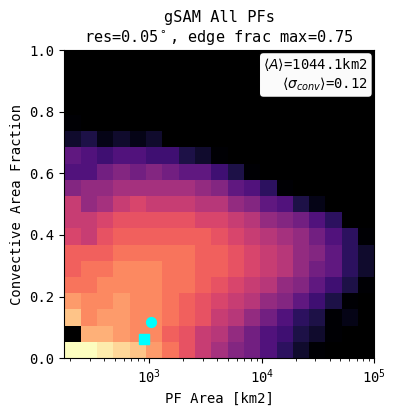

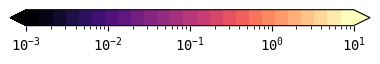

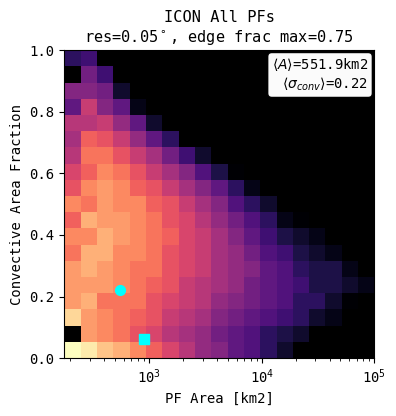

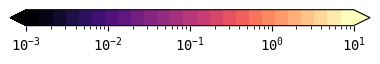

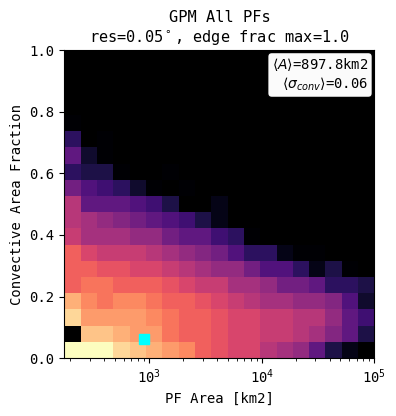

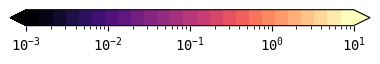

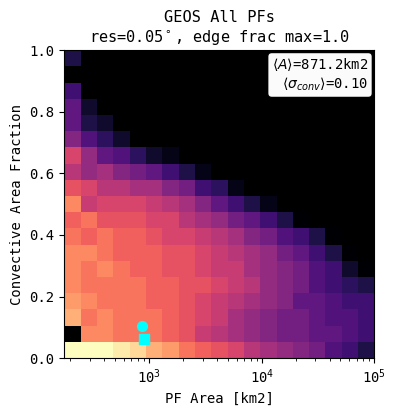

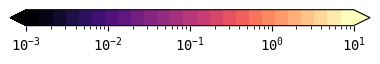

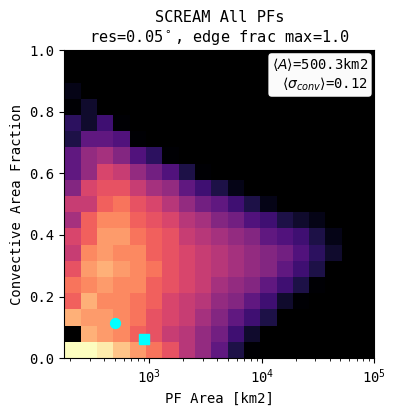

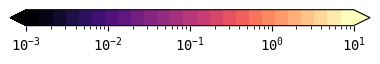

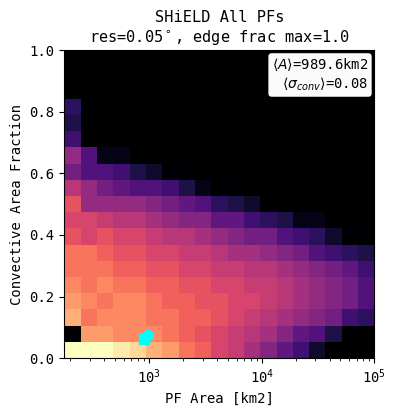

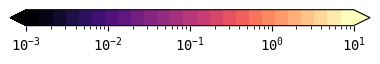

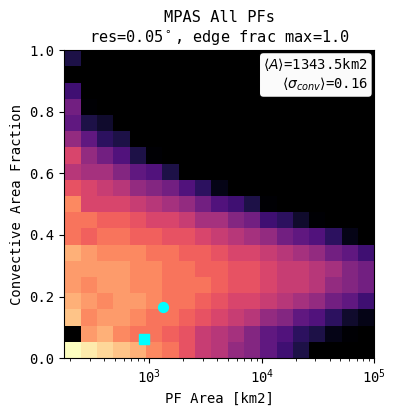

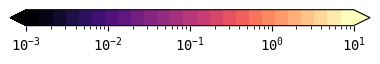

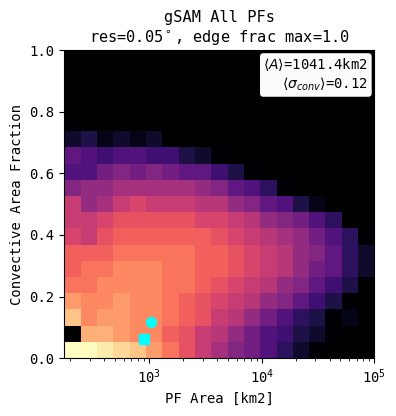

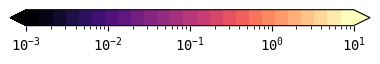

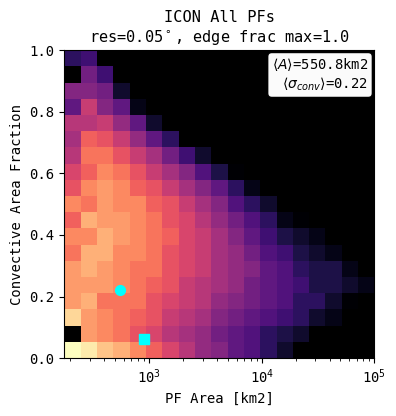

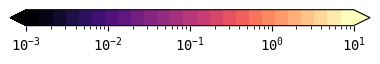

In [41]:
# Set Plotting Parameters
mean_color = 'cyan'
obs_marker = 's'
model_marker = 'o'
x_bins = np.logspace(2.25, 5, 20)
y_bins = np.linspace(0, 1, 20)
cmap = discrete_cmap(plt.cm.magma, 25)
norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
cmap.set_under('black')
cmap.set_bad('black')

# Plot PDF
for _EDGE_FRAC_MAX in [0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]:
    _RES_DEG = _RES.replace('p', '.')
    # Make the plot
    for source, df in feature_stats_dict.items():
        df = df.filter(
            pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX
        )
    # Make the plot
        x_data = df['area_km2']
        y_data = df['px_ge_10mmhr'] / df['size_px']

        fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
            x_data=x_data,
            y_data=y_data,
            x_bins=x_bins,
            y_bins=y_bins,
            data_to_bin=None,
            statistic='count',
            density=True,
            cmap=cmap,
            norm=norm,
            figsize=(4,4),
            return_data=True,
            return_colorbar_separate=True
        )

        # Add marker showing the average value
        def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
            mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
            ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
            if add_text:
                text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
                ax.text(
                    0.98, 0.98, text,
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=10,
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor="white",
                        alpha=0.99,
                        edgecolor="black",
                    ),
                )
            if legend:
                ax.legend(loc='upper left', fontsize=12)

        if source=="GPM":
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label=None, add_text=True)
            x_obs, y_obs = x_data, y_data
        else:
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label='None', add_text=True)
            _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM', add_text=False)
        ax.set_title(
            f'{source} All PFs\n'
            fr'res={_RES_DEG}$^\circ$, edge frac max={_EDGE_FRAC_MAX}',
            fontsize=11,
        )
        ax.set_xscale('log')
        ax.set_xlabel('PF Area [km2]')
        ax.set_ylabel('Convective Area Fraction')


        save_figure(fig, f'AllPFs_A_CAF_JointPDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}.pdf')
        save_figure(cbar_fig, f'AllPFs_A_CAF_JointPDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}_colorbar.pdf')


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_GPM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_GEOS_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_SCREAM_EdgeFracMax0.0_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_mor

/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/plotting.py:69: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_SHiELD_EdgeFracMax0.05_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_MPAS_EdgeFracMax0.05_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_MPAS_EdgeFracMax0.05_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_gSAM_EdgeFracMax0.05_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_gSAM_EdgeFracMax0.05_Res_0.05_Accum_15min_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ExPFs_A_CAF_JointPDF_ICON_EdgeFracMax0.05_Res_0.05_Accum_15min.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extre

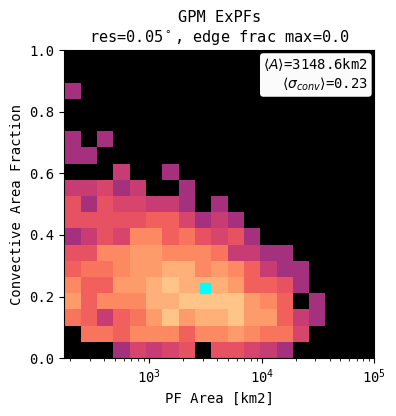

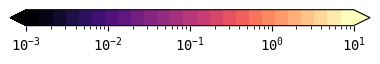

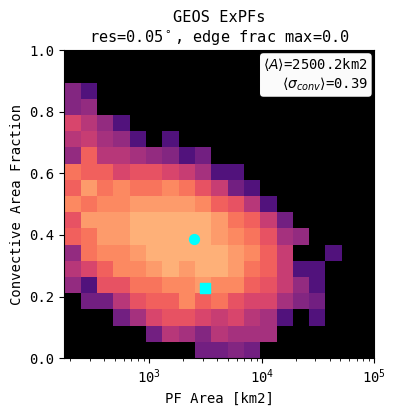

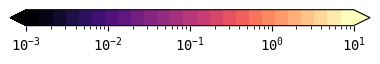

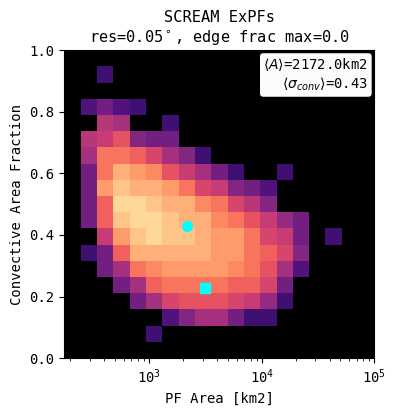

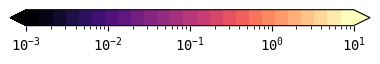

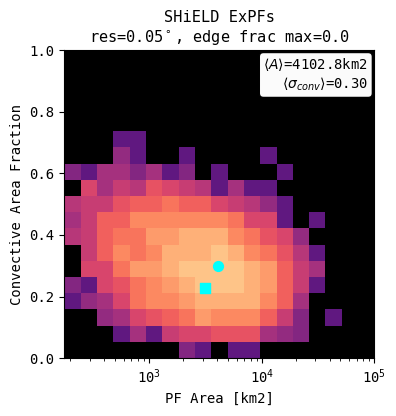

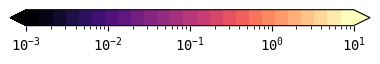

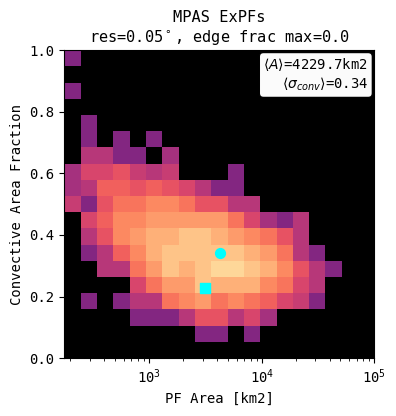

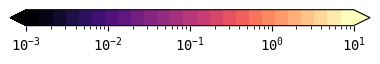

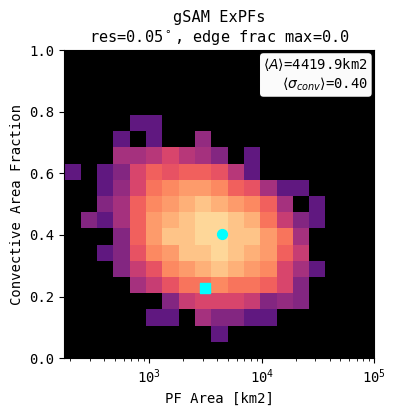

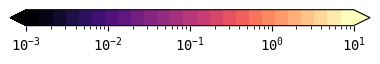

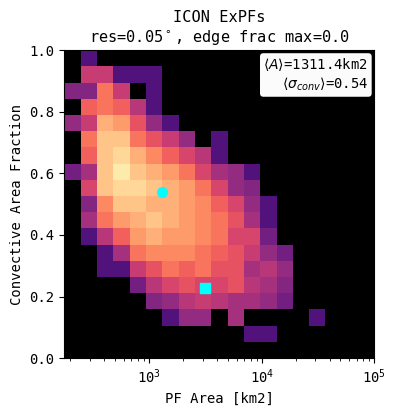

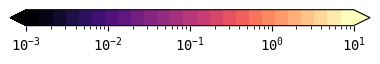

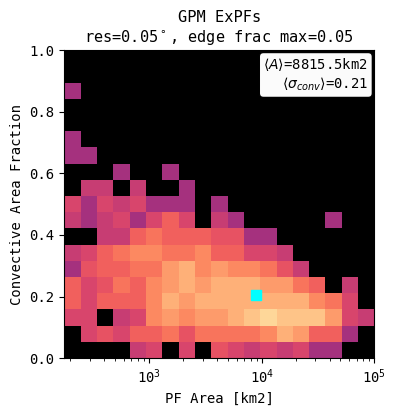

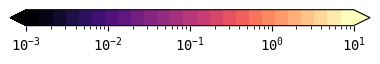

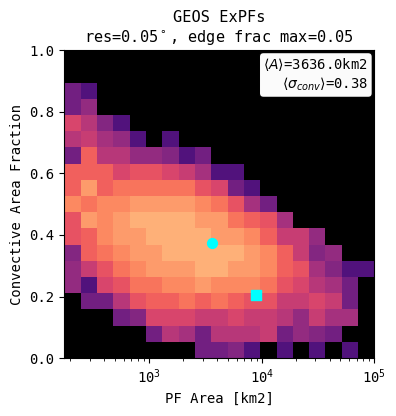

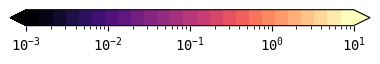

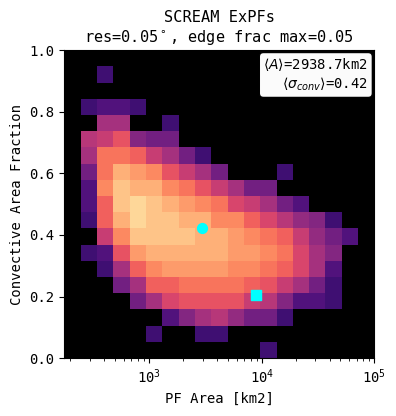

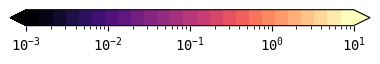

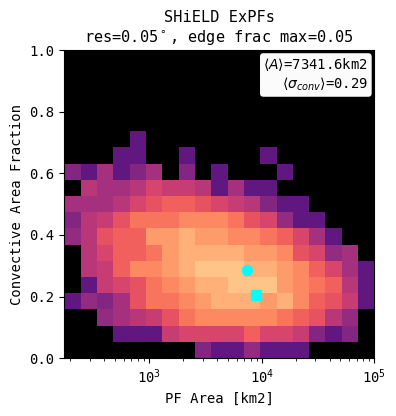

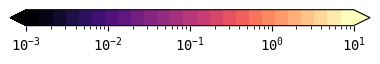

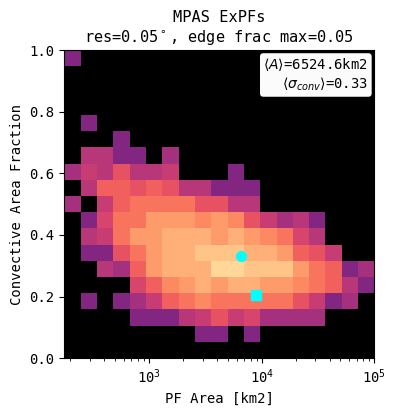

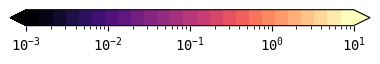

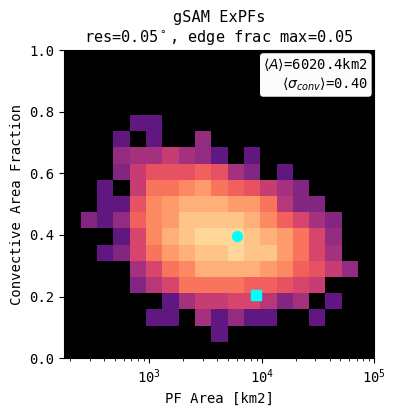

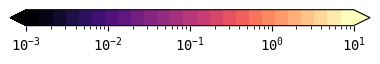

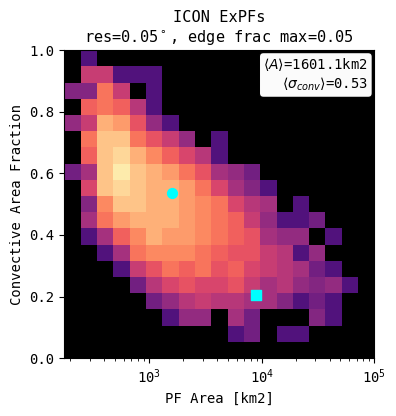

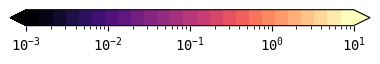

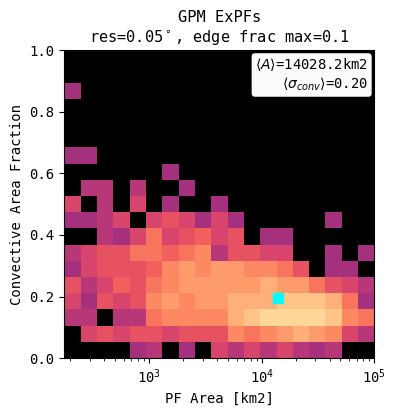

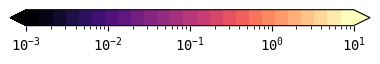

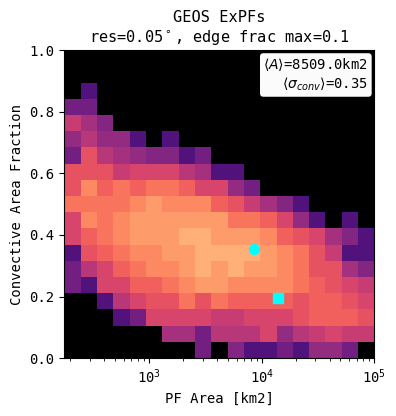

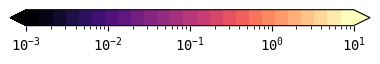

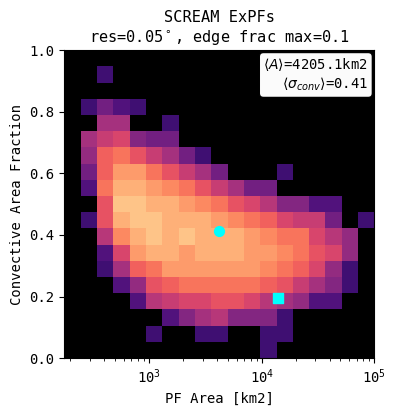

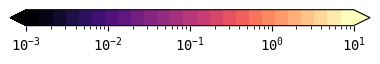

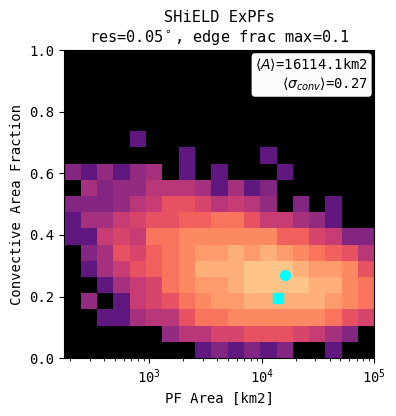

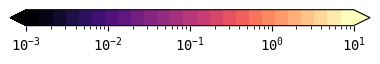

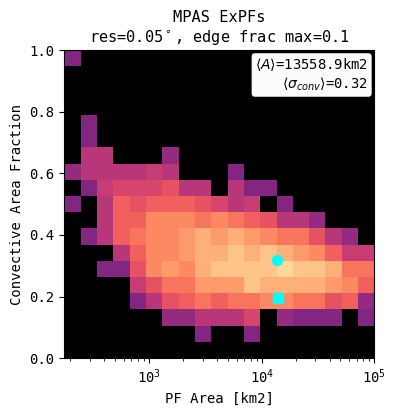

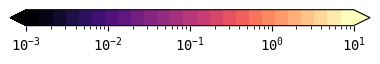

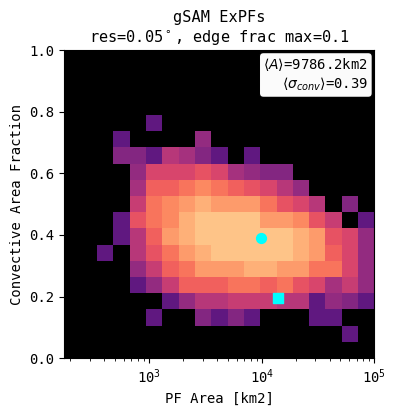

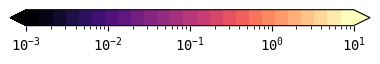

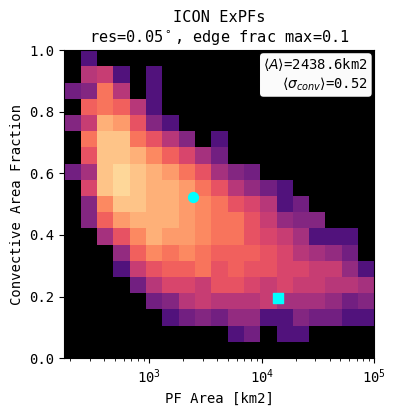

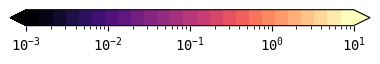

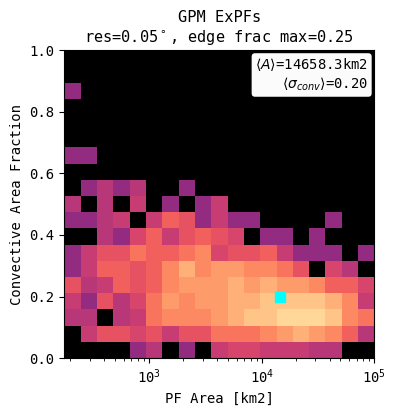

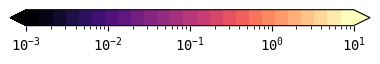

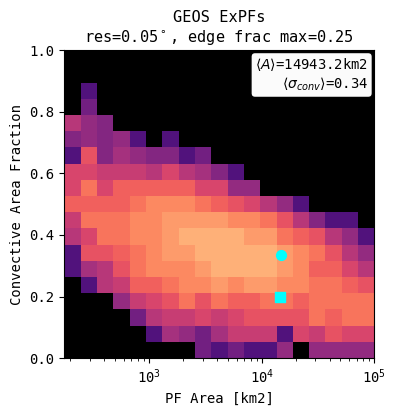

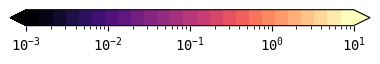

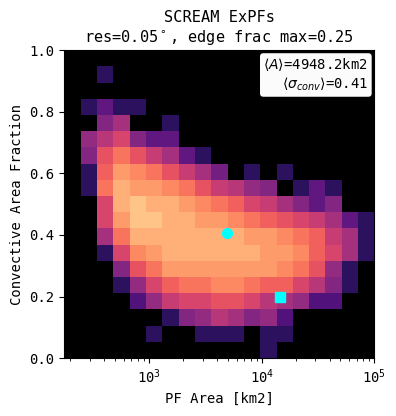

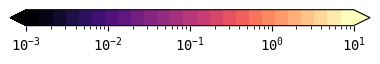

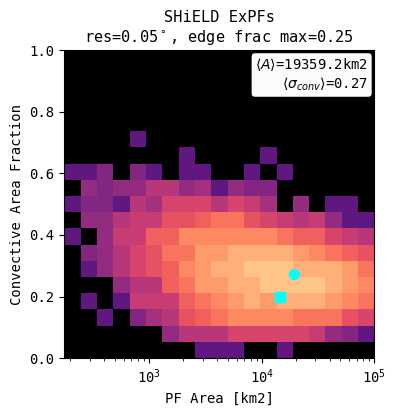

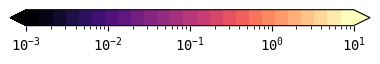

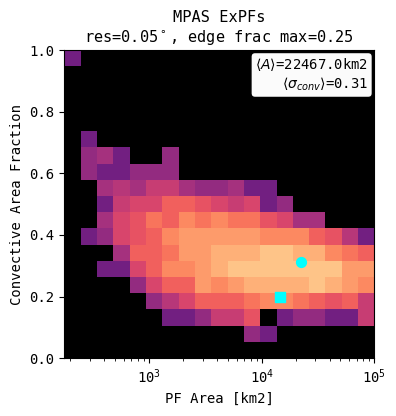

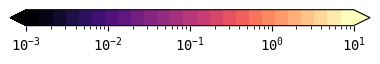

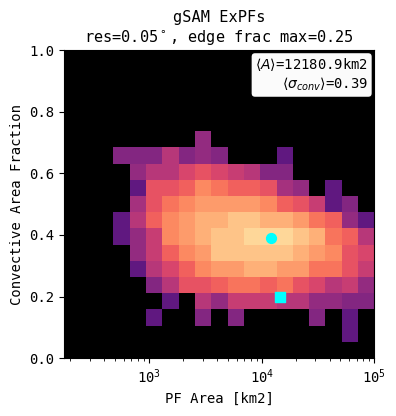

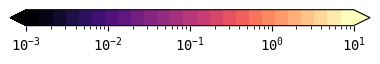

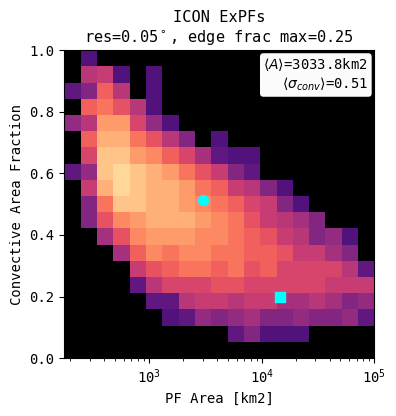

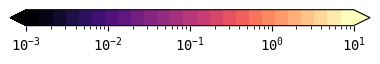

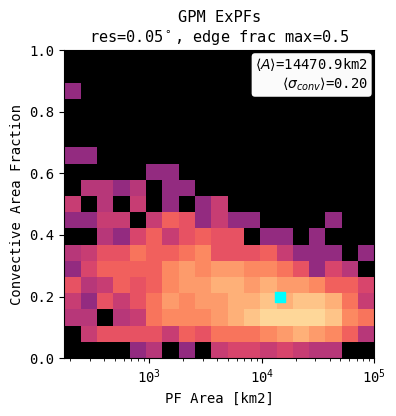

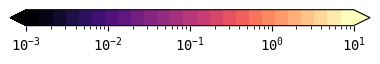

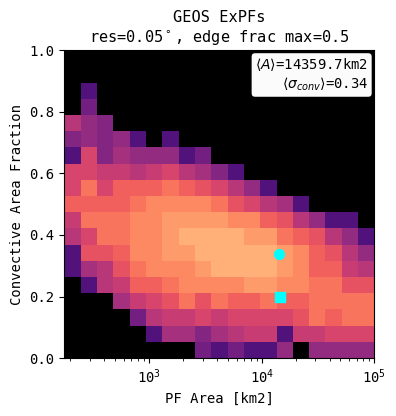

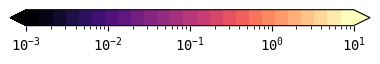

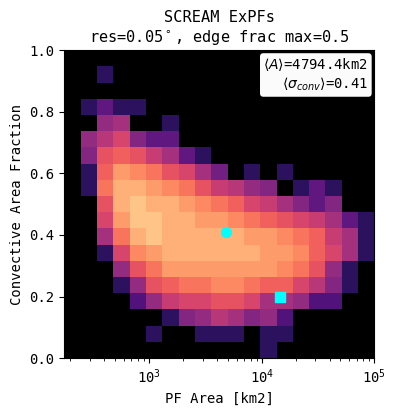

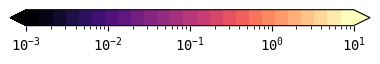

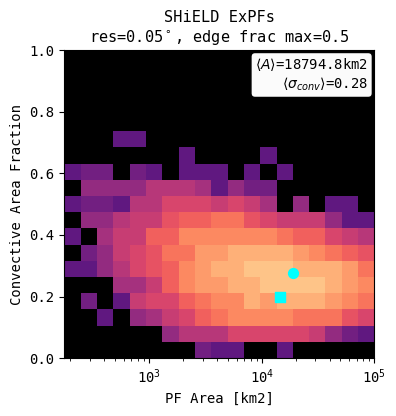

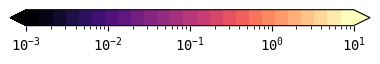

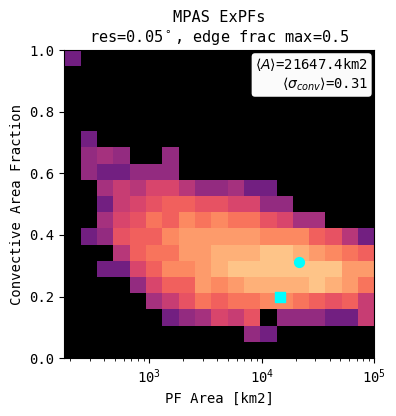

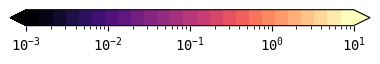

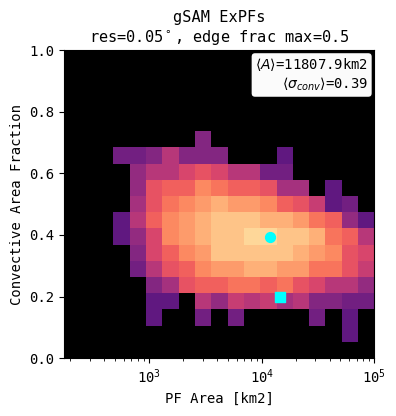

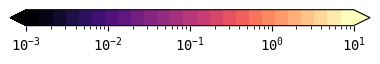

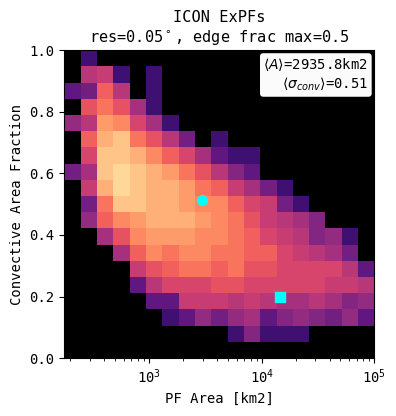

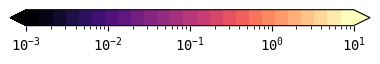

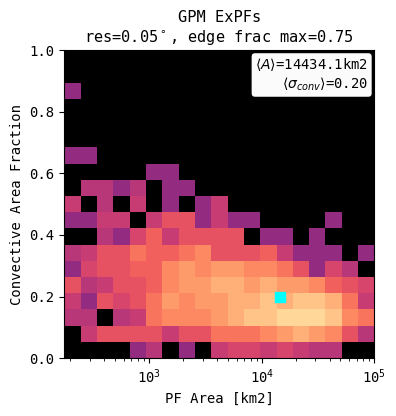

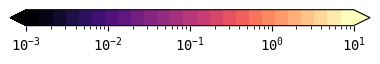

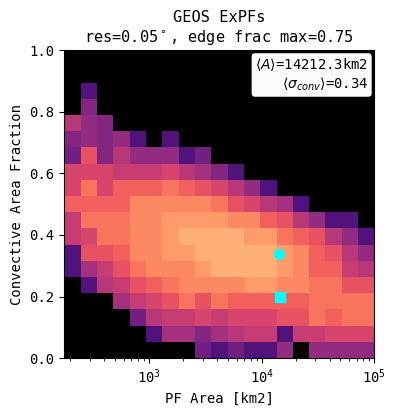

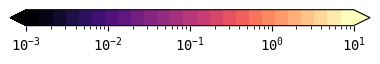

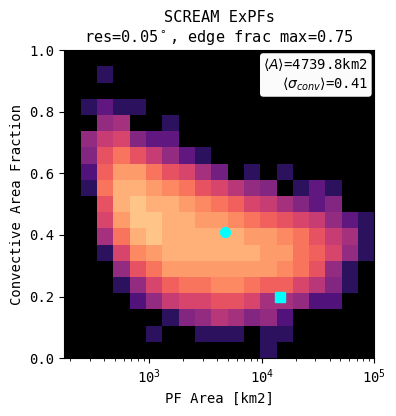

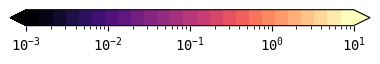

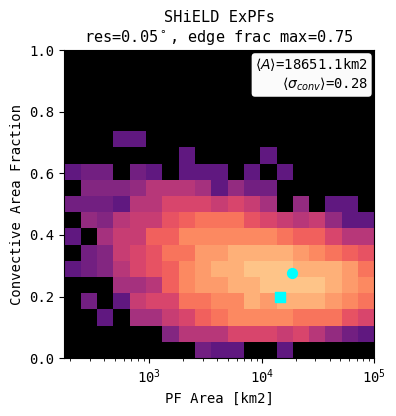

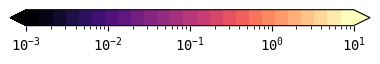

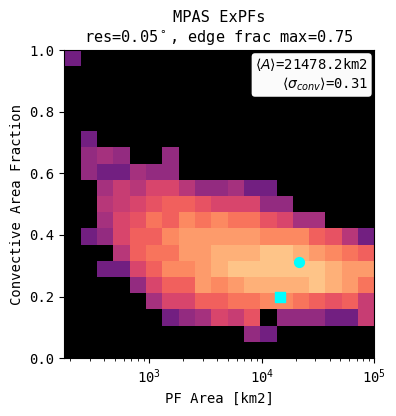

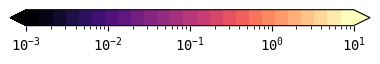

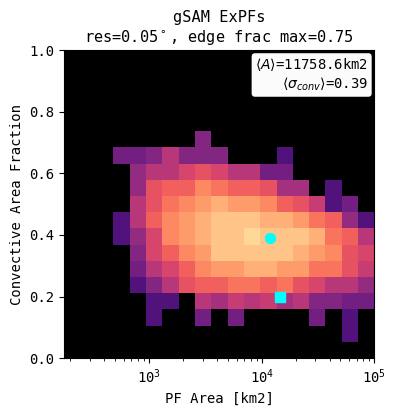

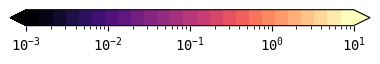

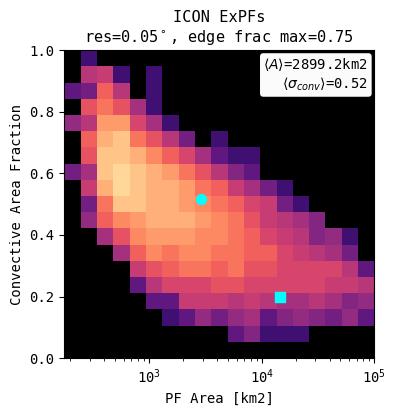

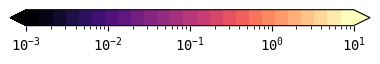

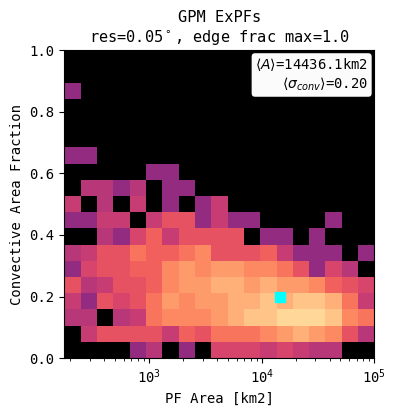

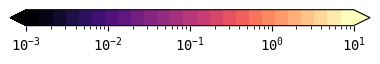

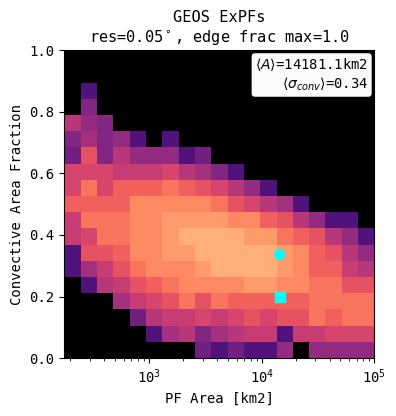

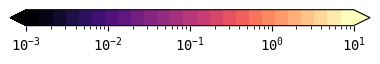

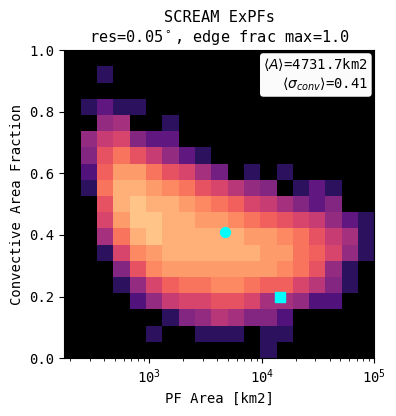

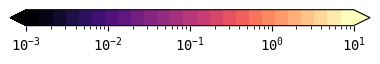

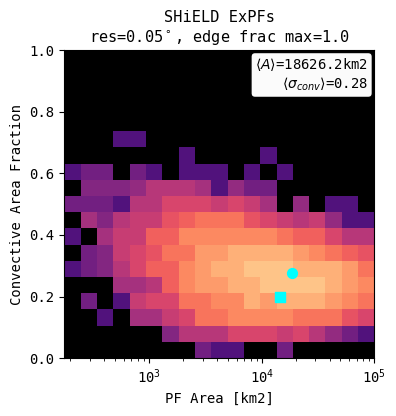

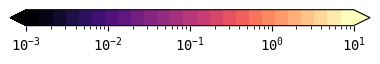

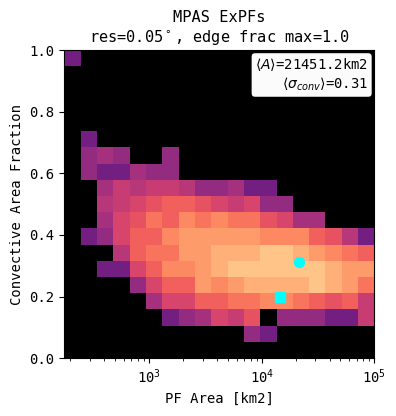

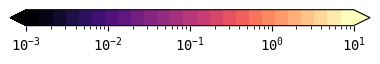

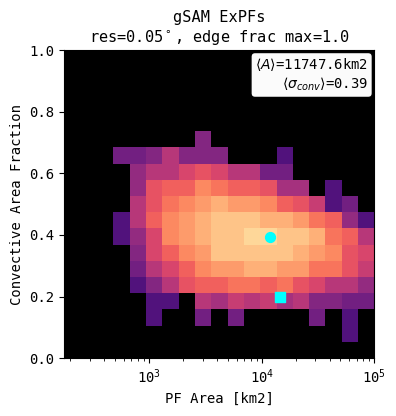

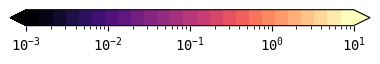

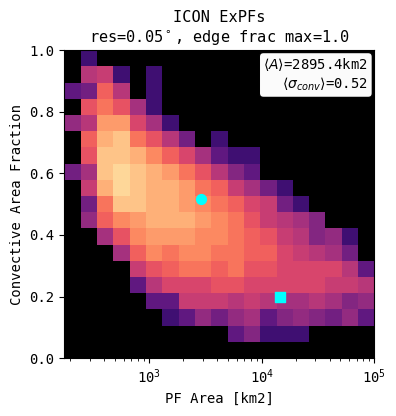

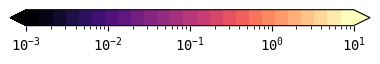

In [43]:
# Set Plotting Parameters
mean_color = 'cyan'
obs_marker = 's'
model_marker = 'o'
x_bins = np.logspace(2.25, 5, 20)
y_bins = np.linspace(0, 1, 20)
cmap = discrete_cmap(plt.cm.magma, 25)
norm = colors.LogNorm(vmin=1e-3, vmax=1e1)
cmap.set_under('black')
cmap.set_bad('black')

# Plot PDF
for _EDGE_FRAC_MAX in [0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]:
    _RES_DEG = _RES.replace('p', '.')
    # Make the plot
    for source, df in feature_stats_dict.items():
        df = df.filter(
            pl.col("cross_track_edge_px") / pl.col("perimeter_px") <= _EDGE_FRAC_MAX
        )
        _EXTREME_THRESH = df['max_precip_mm_hr'].quantile(0.99)
        df = df.filter(
            pl.col("max_precip_mm_hr") >= _EXTREME_THRESH
        )

    # Make the plot
        x_data = df['area_km2']
        y_data = df['px_ge_10mmhr'] / df['size_px']

        fig, ax, cbar_fig, cbar_ax, data = plot_mean_stat(
            x_data=x_data,
            y_data=y_data,
            x_bins=x_bins,
            y_bins=y_bins,
            data_to_bin=None,
            statistic='count',
            density=True,
            cmap=cmap,
            norm=norm,
            figsize=(4,4),
            return_data=True,
            return_colorbar_separate=True
        )

        # Add marker showing the average value
        def _plot_mean(ax, x_data, y_data, color, marker, label, legend=False, add_text=False):
            mean_x, mean_y = np.nanmean(x_data), np.nanmean(y_data)
            ax.scatter(mean_x, mean_y, label=label, color=color, marker=marker, s=50)
            if add_text:
                text = fr"$\langle A\rangle$={mean_x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={mean_y:.2f}"
                ax.text(
                    0.98, 0.98, text,
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=10,
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor="white",
                        alpha=0.99,
                        edgecolor="black",
                    ),
                )
            if legend:
                ax.legend(loc='upper left', fontsize=12)

        if source=="GPM":
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=obs_marker, label=None, add_text=True)
            x_obs, y_obs = x_data, y_data
        else:
            _plot_mean(ax, x_data, y_data, color=mean_color, marker=model_marker, label='None', add_text=True)
            _plot_mean(ax, x_obs, y_obs, color=mean_color, marker=obs_marker, label='GPM', add_text=False)
        ax.set_title(
            f'{source} ExPFs\n'
            fr'res={_RES_DEG}$^\circ$, edge frac max={_EDGE_FRAC_MAX}',
            fontsize=11,
        )
        ax.set_xscale('log')
        ax.set_xlabel('PF Area [km2]')
        ax.set_ylabel('Convective Area Fraction')


        save_figure(fig, f'ExPFs_A_CAF_JointPDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}.pdf')
        save_figure(cbar_fig, f'ExPFs_A_CAF_JointPDF_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_Res_{_RES_DEG}_Accum_{_ACCUM}_colorbar.pdf')


# Looking at Archived Data

In [43]:
old_features = load_pickled_archived_features()
old_features['GEOS']['number_pixels'].min()

5

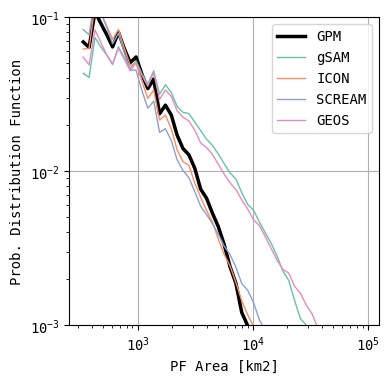

In [26]:
old_features = load_pickled_archived_features()
fig, ax = plt.subplots(figsize=(4,4))
for source, df in old_features.items():
    area = df['number_pixels']*gpm_area_factor()

    def _get_source_line_params(source):
        if source == 'GPM':
            color='black'
            lw = 2.5
            linestyle='solid'
        else:
            color=None
            lw = 1.0
            linestyle='solid'

        return {'color': color, 'lw': lw, 'linestyle': linestyle}

    bins = np.logspace(2.5, 5, 50)
    counts = binned_statistic(
        area,
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()

    line_params = _get_source_line_params(source)
    ax.plot(
        array_midpoints(bins),
        pdf,
        label=source,
        color=line_params['color'],
        lw=line_params['lw'],
        linestyle=line_params['linestyle']
    )

    ax.set_xscale('log')
    ax.legend()
    ax.grid()
    ax.set_ylim(1e-3, 1e-1)
    ax.set_yscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Prob. Distribution Function')

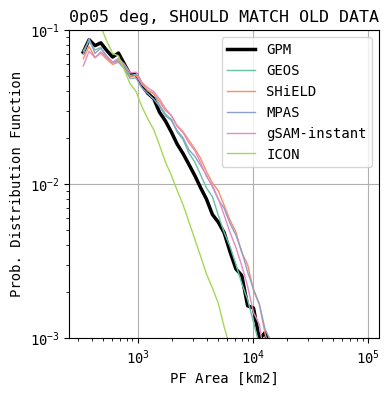

In [44]:
# Sweep parameters
edge_frac_max_list = [0.0]

for _EDGE_FRAC_MAX in edge_frac_max_list:

    # Load features
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res="0p05", edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum='15min', res='0p05', edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        # 'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum='15min', res='0p05', edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum='15min', res='0p05', edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum='15min', res='0p05', edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        'gSAM-instant': load_dyamond_feature_stats('gSAM-4km', accum='instant', res='0p05', edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum='15min', res='0p05', edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN, area_min=5*gpm_area_factor()),
    }

    def _get_source_line_params(source):
        if source == 'GPM':
            color='black'
            lw = 2.5
            linestyle='solid'
        elif source == "IMERG":
            color='black'
            lw = 2.5
            linestyle='dashed'
        else:
            color=None
            lw = 1.0
            linestyle='solid'

        return {'color': color, 'lw': lw, 'linestyle': linestyle}
            

    # Make the plot
    fig, ax = plt.subplots(figsize=(4,4))

    # Plot PDF
    for source, df in feature_stats_dict.items():
        bins = np.logspace(2.5, 5, 50)
        counts = binned_statistic(
            df['area_km2'],
            None,
            'count', 
            bins=bins
        ).statistic
        pdf = counts / counts.sum()
    
        line_params = _get_source_line_params(source)
        ax.plot(
            array_midpoints(bins),
            pdf,
            label=source,
            color=line_params['color'],
            lw=line_params['lw'],
            linestyle=line_params['linestyle']
        )

    ax.set_xscale('log')
    ax.legend()
    ax.grid()
    ax.set_ylim(1e-3, 1e-1)
    ax.set_yscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Prob. Distribution Function')
    ax.set_title(f'0p05 deg, SHOULD MATCH OLD DATA')

# Claude Workspace

Comparing `data/old_data/combined_features.pkl` (the first-generation analysis, plotted above)
against the new 0.05 deg CSVs, for the sources that exist in both: GPM, GEOS, ICON and gSAM.
SCREAM is in the pickle but has no new 0.05 deg file yet.

The cells below work through, in order: what cuts the old data already has applied, how many
rows it has per feature, how wide its swaths were, whether the underlying precipitation field
is even the same, and finally which of those differences actually moves the size PDF.

In [2]:
# --- Setup: old (pickled) vs new (0.05 deg CSV) feature data -----------------
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from scipy.spatial import cKDTree
from src.loading import DYAMOND_DATA_DIR

PX_AREA_FLAT = gpm_area_factor()  # 30.91 km2, the single pixel area the old analysis used

# Old pickle key -> new 0.05 deg file. SCREAM has no 0.05 deg file in the new pipeline.
NEW_0P05 = {
    "GEOS": ("GEOS-3km", "GEOS-3km_features_15minaccum_0p05deg.csv"),
    "ICON": ("ICON-SAP-5km", "ICON-SAP-5km_features_15minaccum_0p05deg.csv"),
    "gSAM": ("gSAM-4km", "gSAM-4km_features_instant_0p05deg.csv"),
}

# Reuse the dict if an earlier cell already unpickled it (the file is ~7 GB).
try:
    old_features
except NameError:
    old_features = load_pickled_archived_features()

_new_cache = {}


def new_raw(source: str) -> pl.DataFrame:
    """Raw new-pipeline 0.05 deg table for one source, no cuts applied."""
    if source not in _new_cache:
        model, fname = NEW_0P05[source]
        _new_cache[source] = pl.read_csv(DYAMOND_DATA_DIR / model / fname)
    return _new_cache[source]


def new_cut(source, edge_frac_max=None, min_px=5, maxpr_min=10.0):
    """New data under the cuts the old data already has baked in (see below)."""
    df = new_raw(source).filter(
        (pl.col("max_precip_mm_hr") >= maxpr_min)
        & (pl.col("size_px") >= min_px)
        & (~pl.col("touches_domain_edge"))
    )
    if edge_frac_max is not None:
        df = df.filter(pl.col("swath_edge_px") / pl.col("perimeter_px") <= edge_frac_max)
    return df


def old_key(source: str) -> list[str]:
    """Columns that identify one physical feature in the old data."""
    return [
        "gpm_filename" if source == "GPM" else "source_file",
        "mean_latitude",
        "mean_longitude",
        "number_pixels",
    ]


# The loader applies no cuts, so first ask what the pickle already had applied to it.
audit = [
    {
        "source": name,
        "rows": df.height,
        "min_number_pixels": df["number_pixels"].min(),
        "min_max_precip": round(float(df["max_precip"].min()), 2),
        "frac_is_complete": round(float(df["is_complete"].mean()), 3),
        "max_abs_lat": round(float(df["mean_latitude"].abs().max()), 2),
    }
    for name, df in old_features.items()
]
print("Cuts already baked into data/old_data/combined_features.pkl:")
pl.DataFrame(audit)

Cuts already baked into data/old_data/combined_features.pkl:


source,rows,min_number_pixels,min_max_precip,frac_is_complete,max_abs_lat
str,i64,i64,f64,f64,f64
"""GPM""",175112,5,10.0,1.0,20.0
"""gSAM""",3756354,5,10.0,1.0,19.98
"""ICON""",6424060,5,10.0,1.0,19.98
"""SCREAM""",6060191,5,10.0,1.0,19.98
"""GEOS""",3209151,5,10.0,1.0,19.98


## 1. The old data has ~6 rows per feature; the new data has one

Every model row in the pickle is one *(feature, swath)* pair, so a feature that sat inside
several of the old swaths appears several times. GPM has exactly one row per feature, because
a GPM feature is only ever seen by the one real swath that observed it. The repetition is not
size-neutral: small features are recorded ~6x, the largest ones ~2x, so the old model curves
are weighted toward small features relative to a one-row-per-feature count.

In [3]:
# --- Difference 1: the old data is NOT one row per feature ------------------
# Count how many rows share the same (snapshot, centroid, size), i.e. are the same
# physical feature recorded more than once.
repeats = []
for name, df in old_features.items():
    n_unique = df.unique(subset=old_key(name)).height
    repeats.append(
        {
            "source": name,
            "rows": df.height,
            "distinct_features": n_unique,
            "rows_per_feature": round(df.height / n_unique, 2),
        }
    )
print("Repetition in the old data:")
print(pl.DataFrame(repeats))

# And how that repetition depends on feature size (the models carry a `swath_idx`;
# GPM does not, because a GPM feature is only ever seen by one real swath).
SIZE_BINS = [(5, 10), (10, 30), (30, 100), (100, 300), (300, 1_000), (1_000, 4_000), (4_000, 13_000)]
rows = []
for name in ["GPM", "GEOS", "ICON", "gSAM"]:
    counts = old_features[name].group_by(old_key(name)).len()
    px, mult = counts["number_pixels"].to_numpy(), counts["len"].to_numpy()
    row = {"source": name}
    for lo, hi in SIZE_BINS:
        m = (px >= lo) & (px < hi)
        row[f"{lo}-{hi}px"] = round(float(mult[m].mean()), 2) if m.any() else None
    rows.append(row)
print("\nMean rows per feature, by feature size:")
pl.DataFrame(rows)

Repetition in the old data:
shape: (5, 4)
┌────────┬─────────┬───────────────────┬──────────────────┐
│ source ┆ rows    ┆ distinct_features ┆ rows_per_feature │
│ ---    ┆ ---     ┆ ---               ┆ ---              │
│ str    ┆ i64     ┆ i64               ┆ f64              │
╞════════╪═════════╪═══════════════════╪══════════════════╡
│ GPM    ┆ 175112  ┆ 175112            ┆ 1.0              │
│ gSAM   ┆ 3756354 ┆ 683299            ┆ 5.5              │
│ ICON   ┆ 6424060 ┆ 1085699           ┆ 5.92             │
│ SCREAM ┆ 6060191 ┆ 991920            ┆ 6.11             │
│ GEOS   ┆ 3209151 ┆ 554606            ┆ 5.79             │
└────────┴─────────┴───────────────────┴──────────────────┘



Mean rows per feature, by feature size:


source,5-10px,10-30px,30-100px,100-300px,300-1000px,1000-4000px,4000-13000px
str,f64,f64,f64,f64,f64,f64,f64
"""GPM""",1.0,1.0,1.0,1.0,1.0,null,null
"""GEOS""",5.98,6.03,5.73,5.14,4.17,2.96,2.1
"""ICON""",5.36,6.1,5.96,5.31,4.36,3.46,2.45
"""gSAM""",5.63,5.68,5.45,5.0,4.42,3.54,3.2


## 2. The old swaths were ~2500 km wide, the new ones are the real ~245 km DPR swath

This is the difference that matters. Estimating a width from the cross-swath spread of feature
centroids: the old "swaths" are 20 deg-wide diagonal bands, 149 of them per snapshot covering
the tropics ~8x over (hence the ~6 rows per feature above). Almost nothing is truncated by a
2500 km-wide swath, so the old model data is effectively the *global* feature population.

In the new data a feature must fit inside a 245 km swath to survive `edge_frac_max = 0`, which
caps the largest surviving feature at ~1200 px, against a population maximum of ~12600 px.

In [4]:
# --- Difference 2: the old "swaths" are ~10x wider than the new ones --------
# Estimate a swath width from the spread of feature centroids perpendicular to the
# swath's own long axis (1st-99th percentile), for a few swaths in each dataset.
def swath_width_km(lat, lon):
    x = np.deg2rad(lon) * 6371 * np.cos(np.deg2rad(lat.mean()))
    y = np.deg2rad(lat) * 6371
    x, y = x - x.mean(), y - y.mean()
    _, vecs = np.linalg.eigh(np.cov(np.c_[x, y].T))
    perp = np.c_[x, y] @ vecs[:, 0]  # eigenvector of the smallest eigenvalue = cross-swath
    return np.percentile(perp, 99) - np.percentile(perp, 1)


old_geos, new_geos = old_features["GEOS"], new_raw("GEOS")
widths = []
for s in [0, 1, 50, 100]:
    o = old_geos.filter(pl.col("swath_idx") == s)
    n = new_geos.filter(pl.col("swath_id") == s)
    widths.append(
        {
            "swath": s,
            "old_width_km": round(float(swath_width_km(o["mean_latitude"].to_numpy(), o["mean_longitude"].to_numpy())), 0),
            "new_width_km": round(float(swath_width_km(n["centroid_lat"].to_numpy(), n["centroid_lon"].to_numpy())), 0),
        }
    )
print("Apparent swath width (DPR is ~245 km):")
print(pl.DataFrame(widths))

n_swaths_old = old_geos["swath_idx"].n_unique()
print(f"\nold: {n_swaths_old} swaths per snapshot, each ~20 deg of longitude wide")
print(f"     -> the tropics are covered ~{n_swaths_old * 20 / 360:.0f}x over, matching the ~6 rows per feature above")
print(f"\nlargest feature in the old data:                 {old_geos['number_pixels'].max():6d} px")
print(f"largest feature in the new data:                 {new_geos['size_px'].max():6d} px")
print(f"largest feature that fits inside one new swath:  {new_geos.filter(pl.col('swath_edge_px') == 0)['size_px'].max():6d} px")

Apparent swath width (DPR is ~245 km):
shape: (4, 3)
┌───────┬──────────────┬──────────────┐
│ swath ┆ old_width_km ┆ new_width_km │
│ ---   ┆ ---          ┆ ---          │
│ i64   ┆ f64          ┆ f64          │
╞═══════╪══════════════╪══════════════╡
│ 0     ┆ 2369.0       ┆ 205.0        │
│ 1     ┆ 2837.0       ┆ 229.0        │
│ 50    ┆ 2482.0       ┆ 241.0        │
│ 100   ┆ 2299.0       ┆ 241.0        │
└───────┴──────────────┴──────────────┘

old: 149 swaths per snapshot, each ~20 deg of longitude wide
     -> the tropics are covered ~8x over, matching the ~6 rows per feature above

largest feature in the old data:                  12631 px
largest feature in the new data:                  12652 px
largest feature that fits inside one new swath:    1209 px


## 3. Is the underlying field the same?

**GEOS: yes, exactly.** Two thirds of the old features in the first snapshot are found in the new
table at identical centroids (to 1e-4 deg), and every one of those has the same `size_px` and the
same `max_precip`. The remaining third are the bounding-box copies described above.

**gSAM: same field, different instants.** No snapshot matches feature-for-feature at any of the
215 new time indices (the new series starts at 03:00 and has 215 snapshots against the old 232),
but the intensity distribution is the same to ~1% (max_precip 50/90/99/99.9th percentile:
26.4/73.3/126.4/173.5 old vs 26.0/72.5/125.2/172.0 new).

**ICON: genuinely a different field.** No match at any time index *and* the new data is much more
intense (30.2/70.2/115.0/155.8 old vs 31.8/102.5/184.4/247.2 new) -- consistent with the old
`pr_3hr_ICON-SAP-5km_..._conservative` file being a 3-hourly mean and the new one a 15 min
accumulation. This is the one model whose size PDF does not line up even once the swath treatment
is matched: its median drops 525 -> 402 km2 with no edge cut applied at all.

In [5]:
# --- Is it even the same underlying precipitation field? --------------------
# Take the first snapshot of each old model, and look for its features in the new
# table at the matching time index. If the field and the feature detection are the
# same, centroids should coincide to machine precision.
match = []
for name in ["GEOS", "ICON", "gSAM"]:
    o_all = old_features[name]
    snap = o_all["source_file"].unique().sort()[0]
    o = o_all.filter(pl.col("source_file") == snap).unique(subset=old_key(name))
    n = new_raw(name).filter(pl.col("time_index") == 0)
    tree = cKDTree(np.c_[n["centroid_lat"].to_numpy(), n["centroid_lon"].to_numpy()])
    d, idx = tree.query(np.c_[o["mean_latitude"].to_numpy(), o["mean_longitude"].to_numpy()], k=1)
    hit = d < 1e-4
    match.append(
        {
            "source": name,
            "old_features": o.height,
            "new_features": n.height,
            "frac_centroids_identical": round(float(hit.mean()), 3),
            "of_those_same_size_px": round(float((o["number_pixels"].to_numpy()[hit] == n["size_px"].to_numpy()[idx[hit]]).mean()), 3) if hit.any() else None,
            "of_those_same_max_precip": round(float(np.isclose(o["max_precip"].to_numpy()[hit], n["max_precip_mm_hr"].to_numpy()[idx[hit]]).mean()), 3) if hit.any() else None,
        }
    )
print("First snapshot (2020-02-01T00:00), old features looked up in the new table:")
print(pl.DataFrame(match))

print("\nWhich file each one came from:")
for name in ["GEOS", "ICON", "gSAM"]:
    print(f"  {name:5s} old: {old_features[name]['source_file'][0].split('/')[-1]}")
    print(f"  {name:5s} new: {new_raw(name)['source_file'][0].split('/')[-1]}\n")

First snapshot (2020-02-01T00:00), old features looked up in the new table:
shape: (3, 6)
┌────────┬──────────────┬──────────────┬───────────────────┬───────────────────┬───────────────────┐
│ source ┆ old_features ┆ new_features ┆ frac_centroids_id ┆ of_those_same_siz ┆ of_those_same_max │
│ ---    ┆ ---          ┆ ---          ┆ entical           ┆ e_px              ┆ _precip           │
│ str    ┆ i64          ┆ i64          ┆ ---               ┆ ---               ┆ ---               │
│        ┆              ┆              ┆ f64               ┆ f64               ┆ f64               │
╞════════╪══════════════╪══════════════╪═══════════════════╪═══════════════════╪═══════════════════╡
│ GEOS   ┆ 2090         ┆ 4503         ┆ 0.666             ┆ 1.0               ┆ 1.0               │
│ ICON   ┆ 4031         ┆ 4716         ┆ 0.0               ┆ null              ┆ null              │
│ gSAM   ┆ 2534         ┆ 4119         ┆ 0.0               ┆ null              ┆ null              │
└

## 4. The size PDFs

Black is the old data exactly as plotted further up this notebook. Red is the new data with
the same cuts but **no swath-edge cut**; blue is the new data with `edge_frac_max = 0`.

- **Models**: black and red lie on top of each other. The entire discrepancy is the swath-edge
  cut, which removes ~all features above ~3000 km2.
- **GPM**: black lies on top of *blue*, not red -- GPM was always truncated by its real swath,
  in the old data as much as in the new one.

So the old figure compared GPM-in-a-245-km-swath against models-in-a-2500-km-swath, and the
models kept a tail that GPM could never show. The new pipeline treats both the same way.

source,curve,n,median_km2
str,str,i64,i64
"""GEOS""","""old (as plotted above)""",3209151,525
"""GEOS""","""old, deduplicated""",554606,556
"""GEOS""","""new, no swath-edge cut""",397343,525
"""GEOS""","""new, edge_frac <= 0.05""",321979,464
"""GEOS""","""new, edge_frac <= 0""",314555,433
…,…,…,…
"""gSAM""","""new, edge_frac <= 0.05""",343020,587
"""gSAM""","""new, edge_frac <= 0""",332340,556
"""GPM""","""old (as plotted above)""",54749,433


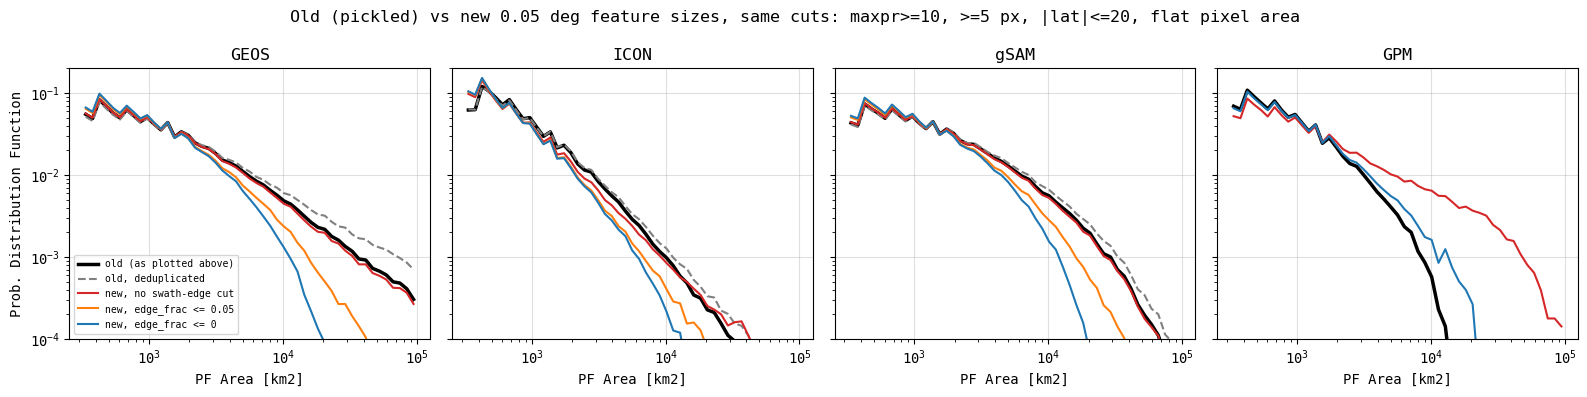

In [6]:
# --- The size PDFs: what actually moves them --------------------------------
BINS = np.logspace(2.5, 5, 50)
MIDS = array_midpoints(BINS)


def size_pdf(area_km2):
    counts = binned_statistic(np.asarray(area_km2), None, "count", bins=BINS).statistic
    return counts / counts.sum()


def flat_area(df, col):
    """Areas the way the old analysis computed them: pixels x one equatorial pixel area."""
    return df[col].to_numpy() * PX_AREA_FLAT


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
summary = []

for ax, name in zip(axes, ["GEOS", "ICON", "gSAM", "GPM"]):
    if name == "GPM":
        old = old_features["GPM"]
        old = old.filter(old["gpm_filename"].str.extract(r"/\d{4}/(\d{2})/", 1) == "02")  # new data is Februaries only
        curves = [
            ("old (as plotted above)", flat_area(old, "number_pixels"), dict(color="black", lw=2.5)),
            ("new, no swath-edge cut", flat_area(load_gpm_feature_stats(1.0, "0p05", edge_frac_max=None).filter(pl.col("size_px") >= 5), "size_px"), dict(color="tab:red", lw=1.5)),
            ("new, edge_frac <= 0", flat_area(load_gpm_feature_stats(1.0, "0p05", edge_frac_max=0.0).filter(pl.col("size_px") >= 5), "size_px"), dict(color="tab:blue", lw=1.5)),
        ]
    else:
        old = old_features[name]
        curves = [
            ("old (as plotted above)", flat_area(old, "number_pixels"), dict(color="black", lw=2.5)),
            ("old, deduplicated", flat_area(old.unique(subset=old_key(name)), "number_pixels"), dict(color="grey", lw=1.5, ls="--")),
            ("new, no swath-edge cut", flat_area(new_cut(name), "size_px"), dict(color="tab:red", lw=1.5)),
            ("new, edge_frac <= 0.05", flat_area(new_cut(name, edge_frac_max=0.05), "size_px"), dict(color="tab:orange", lw=1.5)),
            ("new, edge_frac <= 0", flat_area(new_cut(name, edge_frac_max=0.0), "size_px"), dict(color="tab:blue", lw=1.5)),
        ]

    for label, area, style in curves:
        ax.plot(MIDS, size_pdf(area), label=label, **style)
        summary.append({"source": name, "curve": label, "n": len(area), "median_km2": round(float(np.median(area)))})

    ax.set(xscale="log", yscale="log", ylim=(1e-4, 2e-1), xlabel="PF Area [km2]", title=name)
    ax.grid(alpha=0.4)

axes[0].set_ylabel("Prob. Distribution Function")
axes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("Old (pickled) vs new 0.05 deg feature sizes, same cuts: maxpr>=10, >=5 px, |lat|<=20, flat pixel area")
fig.tight_layout()

pl.DataFrame(summary)

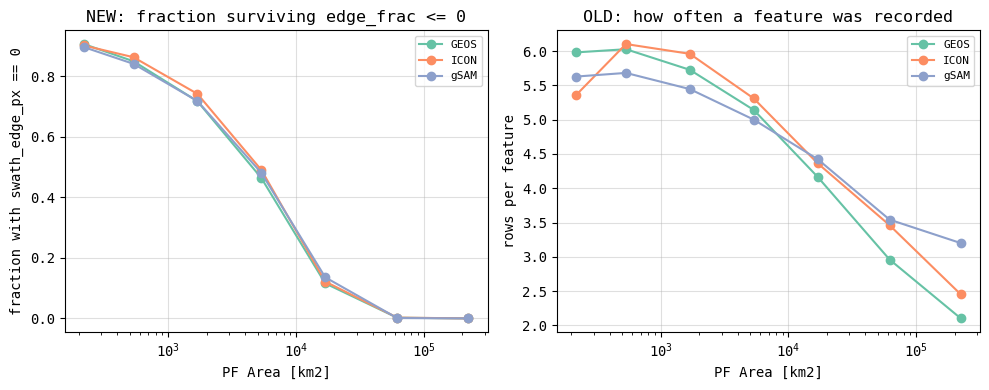

In [7]:
# --- Why the tail disappears: the edge cut is a size filter -----------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
centres = [np.sqrt(lo * hi) * PX_AREA_FLAT for lo, hi in SIZE_BINS]

for name in ["GEOS", "ICON", "gSAM"]:
    new = new_cut(name)
    frac_interior, mult = [], []
    counts = old_features[name].group_by(old_key(name)).len()
    px_old, mult_old = counts["number_pixels"].to_numpy(), counts["len"].to_numpy()
    for lo, hi in SIZE_BINS:
        s = new.filter((pl.col("size_px") >= lo) & (pl.col("size_px") < hi))
        frac_interior.append(float((s["swath_edge_px"] == 0).mean()) if s.height else np.nan)
        m = (px_old >= lo) & (px_old < hi)
        mult.append(float(mult_old[m].mean()) if m.any() else np.nan)
    axes[0].plot(centres, frac_interior, "o-", label=name)
    axes[1].plot(centres, mult, "o-", label=name)

axes[0].set(xscale="log", xlabel="PF Area [km2]", ylabel="fraction with swath_edge_px == 0",
            title="NEW: fraction surviving edge_frac <= 0")
axes[1].set(xscale="log", xlabel="PF Area [km2]", ylabel="rows per feature",
            title="OLD: how often a feature was recorded")
for ax in axes:
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)
fig.tight_layout()

## 5. Smaller differences

None of these move the PDF much, but they are worth knowing about -- in particular the third
one, which silently drops a whole size bin in the cell above titled "SHOULD MATCH OLD DATA".

In [8]:
# --- The smaller differences, for completeness ------------------------------
new_geos = new_raw("GEOS")

# 1. Pixel area convention: old = flat 30.91 km2 everywhere, new = cos(lat)-accurate.
ratio = (new_geos["area_km2"] / new_geos["size_px"] / PX_AREA_FLAT)
print(f"new area_km2 / (size_px * {PX_AREA_FLAT:.2f}): min {ratio.min():.3f}, median {ratio.median():.3f}"
      "   <- new areas are up to 6% smaller at the edge of the domain")

# 2. Minimum feature size: old 5 px, new 4 px.
print(f"\nsmallest feature -- old: {old_features['GEOS']['number_pixels'].min()} px, new: {new_geos['size_px'].min()} px")

# 3. So `area_min=5*gpm_area_factor()` is NOT the same as ">= 5 px" in the new data:
#    a 5 px feature away from the equator has area < 5 * 30.91 km2 and is dropped.
five_px = new_geos.filter(pl.col("size_px") == 5)
kept = float((five_px["area_km2"] >= 5 * PX_AREA_FLAT).mean())
print(f"5 px features kept by area_min=5*gpm_area_factor(): {kept:.3%}  <- use size_px >= 5 instead")

# 4. GPM sampling: the old set is Jan-Mar, the new one is February only (same regions).
old_gpm = old_features["GPM"]
new_gpm = load_gpm_feature_stats(1.0, "0p05", edge_frac_max=0.0)
old_month = old_gpm["gpm_filename"].str.extract(r"/\d{4}/(\d{2})/", 1)
old_region = old_gpm["gpm_filename"].str.extract(r"_([A-Za-z0-9]+)\.nc$", 1)
print(f"\nGPM months  -- old: {sorted(old_month.unique())}, new: ['02']")
print(f"GPM regions -- old: {sorted(old_region.unique())}")
print(f"               new: {sorted(new_gpm['region'].unique())}")
print(f"GPM features (Feb, maxpr>=10, complete, >=5 px) -- old: {old_gpm.filter(old_month == '02').height}, "
      f"new: {new_gpm.filter(pl.col('size_px') >= 5).height}")

new area_km2 / (size_px * 30.91): min 0.940, median 0.990   <- new areas are up to 6% smaller at the edge of the domain

smallest feature -- old: 5 px, new: 4 px
5 px features kept by area_min=5*gpm_area_factor(): 0.000%  <- use size_px >= 5 instead

GPM months  -- old: ['01', '02', '03'], new: ['02']
GPM regions -- old: ['AFC', 'CIO', 'EPO', 'H01', 'H05', 'SAM', 'SAS', 'WMP']
               new: ['AFC', 'CIO', 'EPO', 'H01', 'H05', 'SAM', 'SAS', 'WMP']
GPM features (Feb, maxpr>=10, complete, >=5 px) -- old: 54749, new: 57728


## Summary

| | old (`combined_features.pkl`) | new (0.05 deg CSVs) |
|---|---|---|
| rows | one per (feature, swath), ~6 per feature | one per feature |
| swath width | ~2500 km (20 deg bands, 149/snapshot, ~8x overlap) | ~245 km, the real DPR swath |
| swath-edge cut | `is_complete`, but harmless at that width | `swath_edge_px / perimeter_px <= edge_frac_max`, removes ~all features > 3000 km2 |
| max precip | `max_precip >= 10` baked in | `maxpr_min=10.0` |
| min size | 5 px | 4 px |
| pixel area | flat 30.91 km2 | cos(lat)-accurate, up to 6% smaller |
| latitude | `abs(lat) <= 20` baked in | `abs_lat_max=20` (GPM), domain limit (models) |
| GPM sampling | Jan-Mar 2015-2022 | February only, 2015-2022 |
| model fields | 3-hourly remap: GEOS identical to new, gSAM same field at different instants, **ICON a different (weaker, time-averaged) field** | 15 min accumulation (gSAM: instantaneous), 3-hourly sampling |

**To reproduce the old model curves with the new data**: `edge_frac_max=None`, `maxpr_min=10`,
`size_px >= 5`, and areas as `size_px * gpm_area_factor()`. That agreement is the check that
the two pipelines are consistent.

**But that is not the comparison you want.** GPM only ever sees inside a 245 km swath, so
leaving the models unfiltered gives them a large-feature tail that the observations cannot
produce. `edge_frac_max = 0` (or 0.05) applied to *both* is the like-for-like choice, and the
new figures are the honest ones -- the old model/GPM tail difference was a sampling artefact.